# Cartesian Pendulum Example (3D, Moving Pivot)

This notebook simulates a 3D Cartesian pendulum with a moving pivot parameterized by environment variable $X$.

**Cartesian pendulum DAE with contextualized moving pivot $u(t;X)$.**  
Using $s(t)\in\mathbb{R}^3$ for the bob position and $u(t;X)\in\mathbb{R}^3$ for the pivot trajectory, the system evolves according to
$$
m\,\ddot s(t)=m\,g_0+\lambda(t)\bigl(s(t)-u(t;X)\bigr),
\qquad
\|s(t)-u(t;X)\|_2^2=\ell^2,
$$
where $g_0=(0,0,-g)^\top$, $\ell>0$ is the rod length, and $\lambda(t)$ is the Lagrange multiplier enforcing the rigid-rod constraint.

**Pivot trajectory parameterization.**  
In our implementation, the pivot motion is given by a single Gaussian-windowed sinusoidal pulse along a direction $q\in\mathbb{R}^3$:
$$
u(t;X)
=
A \exp\!\left(-\frac{(t-t_0)^2}{2\tau^2}\right)
\sin\!\bigl(\omega (t-t_0)\bigr)\,q,
$$
where $a_0\in\mathbb{R}^3$ is the baseline pivot location and
$$
X=(A,\omega,\tau,t_0,q)
$$
Here $A$ controls the pulse amplitude, $\omega$ the oscillation frequency, $\tau$ the temporal width, $t_0$ the pulse center, $q$ the excitation direction, and $a_0$ the baseline pivot location.



**Context variable $X$.**  
The variable $q$ and $a_0$ are pre-fixed across samples, where $q=(1,0,0)^T$ and then concatenated into $X$, while
$$
A\sim \mathrm{Uniform}(0.10,0.35),\qquad
\omega\sim \mathrm{Uniform}(1.0,3.0),\qquad
\tau\sim \mathrm{Uniform}(0.45,1.2).
$$
And for a sequence of $t\in[0,T]$, the pulse center time is set to be $t_0 = \frac T 2$


**Initialization.**  
Given a sampled context $X$, the pivot trajectory $u(t;X)$ is fully determined, so in particular the initial position and velocity of pivot,
$$
u(0;X)
\qquad\text{and}\qquad
\dot u(0;X),
$$
are known. To initialize the bob state, we specify an initial rod direction $n_0\in\mathbb{R}^3$ and an initial relative velocity $v_0^{\mathrm{rel}}\in\mathbb{R}^3$. The rod direction is required to satisfy
$$
\|n_0\|_2=1,
$$
and the bob position is initialized as
$$
s(0)=u(0;X)+\ell n_0.
$$
This ensures the position constraint
$$
\|s(0)-u(0;X)\|_2=\ell.
$$

To satisfy the velocity consistency condition of the DAE, the relative velocity must lie in the tangent space of the constraint manifold, namely
$$
n_0^\top v_0^{\mathrm{rel}}=0.
$$
More generally, given a relative velocity $v_0^{\mathrm{rel}}$ between bob and pivot, we project it onto the tangent space by
$$
\tilde v_0^{\mathrm{rel}}
=
v_0^{\mathrm{rel}}
-
(n_0^\top v_0^{\mathrm{rel}})\,n_0.
$$
The bob velocity is then initialized as
$$
\dot s(0)=\dot u(0;X)+\tilde v_0^{\mathrm{rel}}.
$$
Equivalently, with $d_0=s(0)-u(0;X)=\ell n_0$, this gives
$$
d_0^\top\bigl(\dot s(0)-\dot u(0;X)\bigr)=0,
$$
which is exactly the required velocity constraint.

In the default setting, we initialize the pendulum in the downward resting configuration relative to the pivot by taking
$$
n_0=-e_z=(0,0,-1)^\top,
\qquad
v_0^{\mathrm{rel}}=0.
$$
Hence
$$
s(0)=u(0;X)-\ell e_z,
\qquad
\dot s(0)=\dot u(0;X),
$$
so the bob starts directly below the pivot and is initially at rest in the pivot-attached frame.

In [2]:
from pathlib import Path
import sys
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0]
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

np.set_printoptions(precision=4, suppress=True)


In [3]:
@dataclass(frozen=True)
class CartesianPendulumParams:
    mass: float = 1.0
    length: float = 1.0
    gravity: float = 9.81

    def validate(self):
        if self.mass <= 0:
            raise ValueError("mass must be positive")
        if self.length <= 0:
            raise ValueError("length must be positive")
        if self.gravity <= 0:
            raise ValueError("gravity must be positive")


def sample_env_X(
    n_samples: int,
    K: int = 2,
    A_max: float = 0.25,
    omega_range: tuple[float, float] = (0.8, 2.0),
    seed: int | None = 0,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    w_min, w_max = omega_range

    X = np.empty((n_samples, 7 * K), dtype=float)
    for k in range(K):
        cols = slice(7 * k, 7 * (k + 1))
        Ax = rng.uniform(0.0, A_max, size=n_samples)
        Ay = rng.uniform(0.0, A_max, size=n_samples)
        Az = rng.uniform(0.0, A_max, size=n_samples)
        w = rng.uniform(w_min, w_max, size=n_samples)
        phix = rng.uniform(0.0, 2.0 * np.pi, size=n_samples)
        phiy = rng.uniform(0.0, 2.0 * np.pi, size=n_samples)
        phiz = rng.uniform(0.0, 2.0 * np.pi, size=n_samples)
        X[:, cols] = np.stack([Ax, Ay, Az, w, phix, phiy, phiz], axis=1)
    return X


def pivot_kinematics(t: float, X: np.ndarray, K: int, a0: np.ndarray):
    N = X.shape[0]
    a = np.broadcast_to(a0, (N, 3)).astype(float).copy()
    a_dot = np.zeros((N, 3), dtype=float)
    a_ddot = np.zeros((N, 3), dtype=float)

    for k in range(K):
        Ax, Ay, Az, w, phix, phiy, phiz = np.split(X[:, 7 * k : 7 * (k + 1)], 7, axis=1)
        sx = np.sin(w * t + phix)
        sy = np.sin(w * t + phiy)
        sz = np.sin(w * t + phiz)
        cx = np.cos(w * t + phix)
        cy = np.cos(w * t + phiy)
        cz = np.cos(w * t + phiz)

        a[:, 0] += (Ax * sx).ravel()
        a[:, 1] += (Ay * sy).ravel()
        a[:, 2] += (Az * sz).ravel()

        a_dot[:, 0] += (Ax * w * cx).ravel()
        a_dot[:, 1] += (Ay * w * cy).ravel()
        a_dot[:, 2] += (Az * w * cz).ravel()

        a_ddot[:, 0] += (-Ax * (w ** 2) * sx).ravel()
        a_ddot[:, 1] += (-Ay * (w ** 2) * sy).ravel()
        a_ddot[:, 2] += (-Az * (w ** 2) * sz).ravel()

    return a, a_dot, a_ddot


def _lambda_closed_form(params: CartesianPendulumParams, d: np.ndarray, rel_v: np.ndarray, a_ddot: np.ndarray):
    ell2 = params.length ** 2
    g0 = np.array([0.0, 0.0, -params.gravity], dtype=float)
    term = np.einsum("ij,ij->i", d, (g0 - a_ddot)) + np.einsum("ij,ij->i", rel_v, rel_v)
    return -(params.mass / ell2) * term


def simulate_cartesian_pendulum(
    params: CartesianPendulumParams,
    t_final: float,
    dt: float,
    X: np.ndarray,
    K: int,
    a0: np.ndarray = np.zeros(3),
    n0: np.ndarray = np.array([1.0, 0.0, 0.0]),
    rel_v0: np.ndarray = np.array([0.0, 0.6, 0.0]),
    project_each_step: bool = True,
):
    params.validate()
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X[None, :]
    if X.shape[1] != 7 * K:
        raise ValueError(f"X must have shape (N, {7*K})")

    N = X.shape[0]
    n_steps = int(np.floor(t_final / dt))
    t = np.linspace(0.0, n_steps * dt, n_steps + 1)

    n0 = np.asarray(n0, dtype=float)
    n0 = n0 / np.linalg.norm(n0)
    rel_v0 = np.asarray(rel_v0, dtype=float)

    r = np.zeros((N, t.size, 3), dtype=float)
    v = np.zeros((N, t.size, 3), dtype=float)
    a_hist = np.zeros((N, t.size, 3), dtype=float)
    lam_hist = np.zeros((N, t.size), dtype=float)

    a_init, a_dot_init, a_ddot_init = pivot_kinematics(t[0], X, K, a0)
    a_hist[:, 0] = a_init
    r[:, 0] = a_init + params.length * n0[None, :]

    # Project initial relative velocity to tangent space of the sphere.
    rel_v = np.broadcast_to(rel_v0, (N, 3)).astype(float).copy()
    d0 = r[:, 0] - a_init
    rel_v -= ((np.einsum("ij,ij->i", d0, rel_v) / (params.length**2))[:, None]) * d0
    v[:, 0] = a_dot_init + rel_v

    g0 = np.array([0.0, 0.0, -params.gravity], dtype=float)

    def rhs(ti: float, ri: np.ndarray, vi: np.ndarray):
        ai, ai_dot, ai_ddot = pivot_kinematics(ti, X, K, a0)
        d = ri - ai
        rel_vi = vi - ai_dot
        lam = _lambda_closed_form(params, d=d, rel_v=rel_vi, a_ddot=ai_ddot)
        dr = vi
        dv = g0[None, :] + (lam[:, None] / params.mass) * d
        return dr, dv, lam

    for i in range(n_steps):
        ti = t[i]
        ri = r[:, i]
        vi = v[:, i]

        k1_r, k1_v, _ = rhs(ti, ri, vi)
        k2_r, k2_v, _ = rhs(ti + 0.5 * dt, ri + 0.5 * dt * k1_r, vi + 0.5 * dt * k1_v)
        k3_r, k3_v, _ = rhs(ti + 0.5 * dt, ri + 0.5 * dt * k2_r, vi + 0.5 * dt * k2_v)
        k4_r, k4_v, _ = rhs(ti + dt, ri + dt * k3_r, vi + dt * k3_v)

        r_next = ri + (dt / 6.0) * (k1_r + 2.0 * k2_r + 2.0 * k3_r + k4_r)
        v_next = vi + (dt / 6.0) * (k1_v + 2.0 * k2_v + 2.0 * k3_v + k4_v)

        a_next, a_dot_next, a_ddot_next = pivot_kinematics(t[i + 1], X, K, a0)

        if project_each_step:
            d = r_next - a_next
            d_norm = np.linalg.norm(d, axis=1, keepdims=True)
            d = params.length * d / np.maximum(d_norm, 1e-12)
            r_next = a_next + d

            rel_v_next = v_next - a_dot_next
            rel_v_next -= ((np.einsum("ij,ij->i", d, rel_v_next) / (params.length**2))[:, None]) * d
            v_next = a_dot_next + rel_v_next

        d_next = r_next - a_next
        rel_v_next = v_next - a_dot_next
        lam_next = _lambda_closed_form(params, d=d_next, rel_v=rel_v_next, a_ddot=a_ddot_next)

        r[:, i + 1] = r_next
        v[:, i + 1] = v_next
        a_hist[:, i + 1] = a_next
        lam_hist[:, i + 1] = lam_next

    d_all = r - a_hist
    constraint_err = np.abs(np.linalg.norm(d_all, axis=2) - params.length)

    # Tangency error: d^T (v - a_dot) should be 0.
    a_dot_all = np.zeros_like(a_hist)
    for j, tj in enumerate(t):
        _, a_dot_t, _ = pivot_kinematics(tj, X, K, a0)
        a_dot_all[:, j] = a_dot_t
    tangency_err = np.einsum("nti,nti->nt", d_all, (v - a_dot_all))

    return {
        "t": t,
        "r": r,
        "v": v,
        "a": a_hist,
        "lambda": lam_hist,
        "constraint_err": constraint_err,
        "tangency_err": tangency_err,
        "X": X,
    }


In [5]:
# Experiment setup (similar role as spring_example params/X/traj block)
seed = 3
params = CartesianPendulumParams(mass=1.0, length=1.0, gravity=9.81)

T = 10.0
dt = 0.005
K = 2
N = 120
a0 = np.array([0.0, 0.0, 0.0])

X = sample_env_X(n_samples=N, K=K, A_max=0.30, omega_range=(0.6, 2.2), seed=seed)
traj = simulate_cartesian_pendulum(
    params=params,
    t_final=T,
    dt=dt,
    X=X,
    K=K,
    a0=a0,
    n0=np.array([0.15, 0.0, -0.9887]),
    rel_v0=np.array([0.0, 0.8, 0.0]),
    project_each_step=True,
)

print("Shapes:")
print("  r:", traj["r"].shape, "a:", traj["a"].shape, "lambda:", traj["lambda"].shape)
print("Mean max constraint error:", np.mean(np.max(traj["constraint_err"], axis=1)))
print("Mean max |tangency error|:", np.mean(np.max(np.abs(traj["tangency_err"]), axis=1)))


Shapes:
  r: (120, 2001, 3) a: (120, 2001, 3) lambda: (120, 2001)
Mean max constraint error: 2.257453483404485e-16
Mean max |tangency error|: 1.0252938544471253e-16


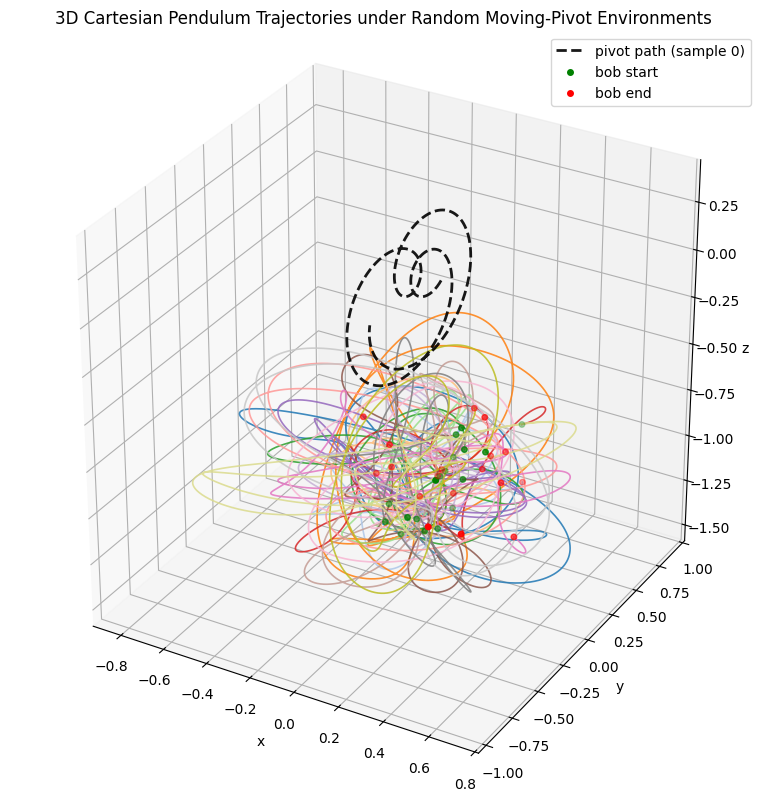

In [6]:
# Visualization 1: many trajectories in 3D (bob + pivot paths)
t = traj["t"]
r = traj["r"]
a = traj["a"]

rng = np.random.default_rng(0)
idx = rng.choice(r.shape[0], size=min(18, r.shape[0]), replace=False)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for k, i in enumerate(idx):
    color = plt.cm.tab20(k % 20)
    ax.plot(r[i, :, 0], r[i, :, 1], r[i, :, 2], color=color, lw=1.2, alpha=0.85)

ax.plot(a[0, :, 0], a[0, :, 1], a[0, :, 2], "k--", lw=2.0, alpha=0.9, label="pivot path (sample 0)")
ax.scatter(r[idx, 0, 0], r[idx, 0, 1], r[idx, 0, 2], s=16, c="green", label="bob start")
ax.scatter(r[idx, -1, 0], r[idx, -1, 1], r[idx, -1, 2], s=16, c="red", label="bob end")

ax.set_title("3D Cartesian Pendulum Trajectories under Random Moving-Pivot Environments")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(loc="upper right")
ax.set_box_aspect((1, 1, 1))
plt.tight_layout()
plt.show()


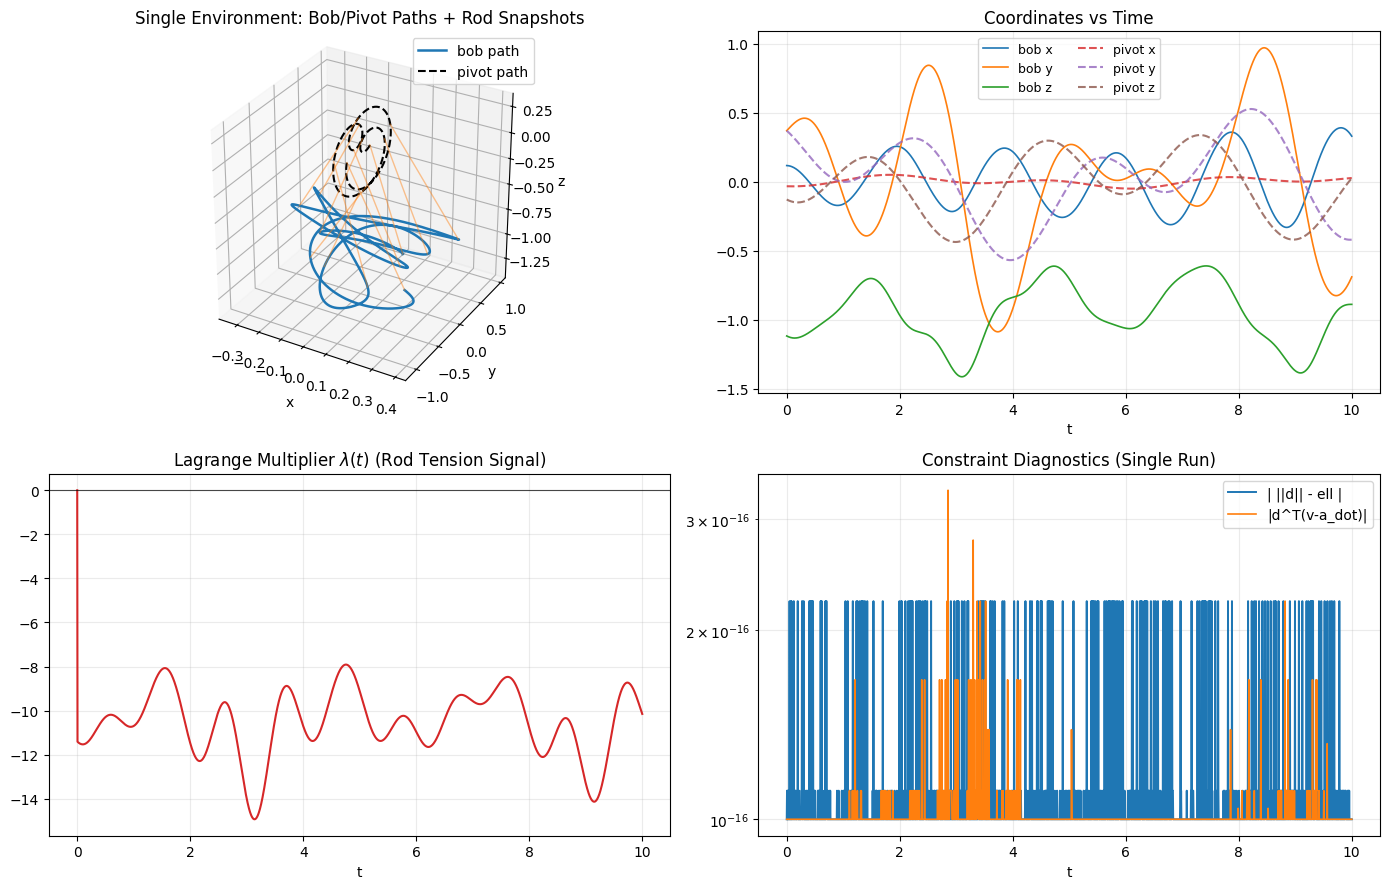

In [7]:
# Visualization 2: single trajectory with rod snapshots + time diagnostics
i = 0
t = traj["t"]
r0 = traj["r"][i]
a0_hist = traj["a"][i]
lam0 = traj["lambda"][i]
cerr0 = traj["constraint_err"][i]
terr0 = traj["tangency_err"][i]

fig = plt.figure(figsize=(14, 9))
ax3d = fig.add_subplot(2, 2, 1, projection="3d")
ax3d.plot(r0[:, 0], r0[:, 1], r0[:, 2], color="tab:blue", lw=1.8, label="bob path")
ax3d.plot(a0_hist[:, 0], a0_hist[:, 1], a0_hist[:, 2], "k--", lw=1.5, label="pivot path")

snap_ids = np.linspace(0, len(t) - 1, 11, dtype=int)
for j in snap_ids:
    ax3d.plot([a0_hist[j, 0], r0[j, 0]], [a0_hist[j, 1], r0[j, 1]], [a0_hist[j, 2], r0[j, 2]],
              color="tab:orange", alpha=0.45, lw=1.0)

ax3d.set_title("Single Environment: Bob/Pivot Paths + Rod Snapshots")
ax3d.set_xlabel("x")
ax3d.set_ylabel("y")
ax3d.set_zlabel("z")
ax3d.legend(loc="upper right")
ax3d.set_box_aspect((1, 1, 1))

ax_pos = fig.add_subplot(2, 2, 2)
ax_pos.plot(t, r0[:, 0], label="bob x", lw=1.2)
ax_pos.plot(t, r0[:, 1], label="bob y", lw=1.2)
ax_pos.plot(t, r0[:, 2], label="bob z", lw=1.2)
ax_pos.plot(t, a0_hist[:, 0], "--", label="pivot x", alpha=0.8)
ax_pos.plot(t, a0_hist[:, 1], "--", label="pivot y", alpha=0.8)
ax_pos.plot(t, a0_hist[:, 2], "--", label="pivot z", alpha=0.8)
ax_pos.set_title("Coordinates vs Time")
ax_pos.set_xlabel("t")
ax_pos.grid(True, alpha=0.25)
ax_pos.legend(ncol=2, fontsize=9)

ax_lam = fig.add_subplot(2, 2, 3)
ax_lam.plot(t, lam0, color="tab:red", lw=1.5)
ax_lam.axhline(0.0, color="k", lw=0.8, alpha=0.7)
ax_lam.set_title(r"Lagrange Multiplier $\lambda(t)$ (Rod Tension Signal)")
ax_lam.set_xlabel("t")
ax_lam.grid(True, alpha=0.25)

ax_err = fig.add_subplot(2, 2, 4)
ax_err.semilogy(t, np.maximum(cerr0, 1e-16), label="| ||d|| - ell |", lw=1.4)
ax_err.semilogy(t, np.maximum(np.abs(terr0), 1e-16), label="|d^T(v-a_dot)|", lw=1.2)
ax_err.set_title("Constraint Diagnostics (Single Run)")
ax_err.set_xlabel("t")
ax_err.grid(True, which="both", alpha=0.25)
ax_err.legend()

plt.tight_layout()
plt.show()


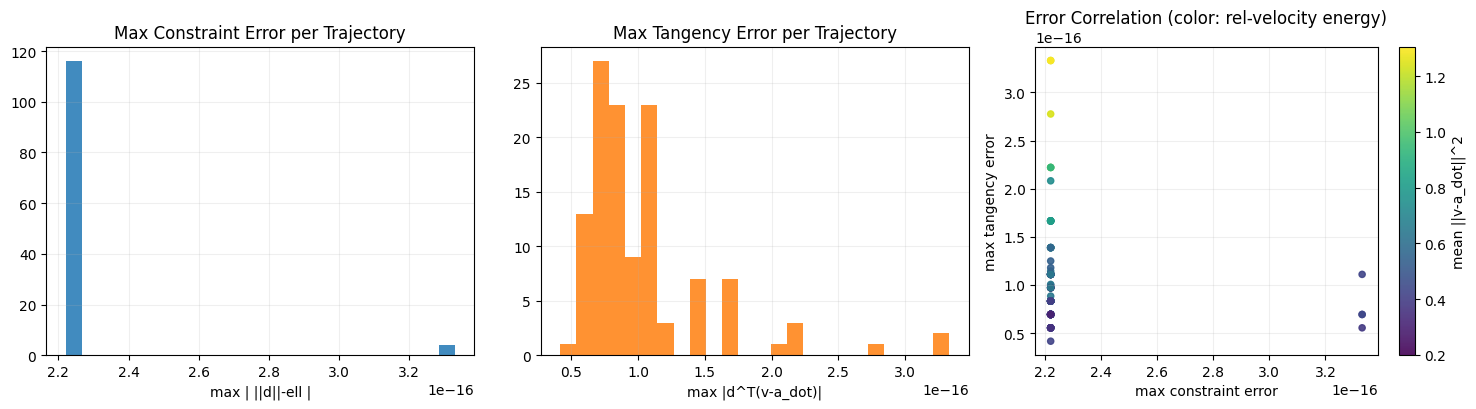

Dataset-level stats:
  median max constraint error: 2.220446049250313e-16
  median max tangency error: 8.326672684688674e-17


In [8]:
# Visualization 3: population-level diagnostics across sampled environments
max_cerr = np.max(traj["constraint_err"], axis=1)
max_terr = np.max(np.abs(traj["tangency_err"]), axis=1)
energy_like = np.mean(np.linalg.norm(traj["v"] - np.gradient(traj["a"], traj["t"], axis=1), axis=2) ** 2, axis=1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].hist(max_cerr, bins=24, color="tab:blue", alpha=0.85)
ax[0].set_title("Max Constraint Error per Trajectory")
ax[0].set_xlabel("max | ||d||-ell |")
ax[0].grid(True, alpha=0.2)

ax[1].hist(max_terr, bins=24, color="tab:orange", alpha=0.85)
ax[1].set_title("Max Tangency Error per Trajectory")
ax[1].set_xlabel("max |d^T(v-a_dot)|")
ax[1].grid(True, alpha=0.2)

sc = ax[2].scatter(max_cerr, max_terr, c=energy_like, cmap="viridis", s=20, alpha=0.9)
ax[2].set_title("Error Correlation (color: rel-velocity energy)")
ax[2].set_xlabel("max constraint error")
ax[2].set_ylabel("max tangency error")
ax[2].grid(True, alpha=0.2)
fig.colorbar(sc, ax=ax[2], label="mean ||v-a_dot||^2")

plt.tight_layout()
plt.show()

print("Dataset-level stats:")
print("  median max constraint error:", np.median(max_cerr))
print("  median max tangency error:", np.median(max_terr))


In [9]:
# Extra pivot trajectory families from your suggestion
def pivot_planar_circle(t, a0, A=0.35, omega=1.2, phi=0.0, R=np.eye(3)):
    t = np.asarray(t, dtype=float)
    base = np.column_stack([A*np.cos(omega*t + phi), A*np.sin(omega*t + phi), np.zeros_like(t)])
    return a0[None, :] + base @ np.asarray(R, dtype=float).T


def pivot_circle_plus_heave(t, a0, A=0.35, B=0.08, omega=1.2, phi_z=np.pi/2, R=np.eye(3)):
    t = np.asarray(t, dtype=float)
    base = np.column_stack([A*np.cos(omega*t), A*np.sin(omega*t), B*np.sin(omega*t + phi_z)])
    return a0[None, :] + base @ np.asarray(R, dtype=float).T


def _plot_pivot_family(t, a, title):
    fig = plt.figure(figsize=(12, 5))
    ax3d = fig.add_subplot(1, 2, 1, projection="3d")
    ax3d.plot(a[:, 0], a[:, 1], a[:, 2], lw=2.2, color="tab:blue")
    ax3d.scatter(a[0, 0], a[0, 1], a[0, 2], c="green", s=30, label="start")
    ax3d.scatter(a[-1, 0], a[-1, 1], a[-1, 2], c="red", s=30, label="end")
    ax3d.set_title(title + " (3D path)")
    ax3d.set_xlabel("x")
    ax3d.set_ylabel("y")
    ax3d.set_zlabel("z")
    ax3d.legend()
    ax3d.set_box_aspect((1, 1, 1))

    ax = fig.add_subplot(1, 2, 2)
    ax.plot(t, a[:, 0], label="a_x", lw=1.6)
    ax.plot(t, a[:, 1], label="a_y", lw=1.6)
    ax.plot(t, a[:, 2], label="a_z", lw=1.6)
    ax.set_title(title + " (components vs time)")
    ax.set_xlabel("t")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


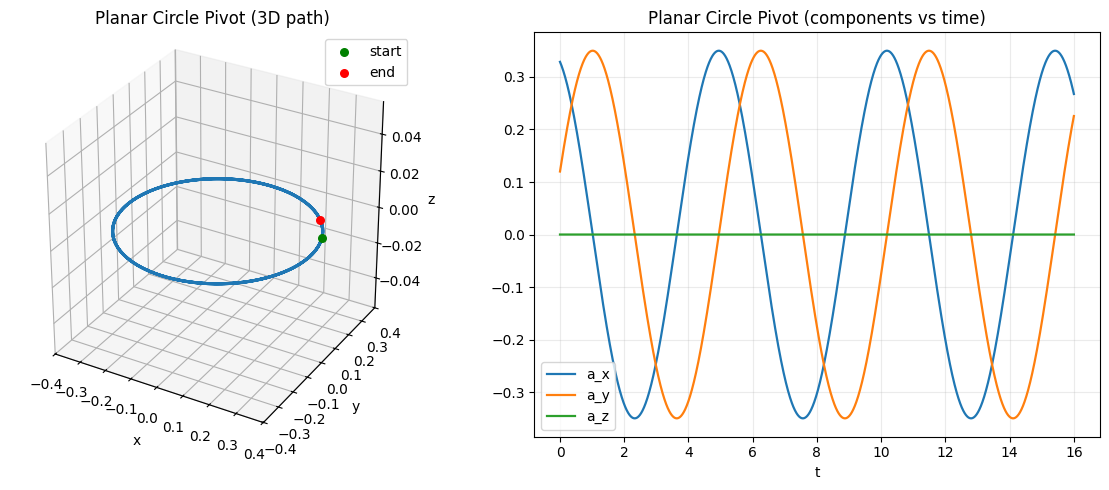

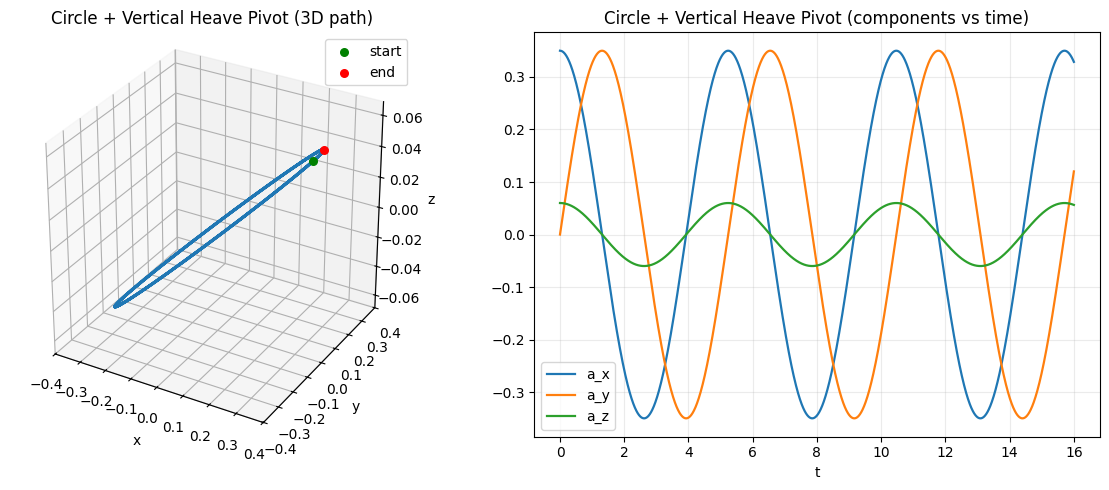

In [10]:
# Visualize the two a(t) families
t_vis = np.linspace(0.0, 16.0, 2000)
a0_vis = np.array([0.0, 0.0, 0.0])

# 2) Planar circle
a_circle = pivot_planar_circle(t_vis, a0=a0_vis, A=0.35, omega=1.2, phi=0.35)
_plot_pivot_family(t_vis, a_circle, "Planar Circle Pivot")

# 4) Circle + vertical heave (B << A)
a_heave = pivot_circle_plus_heave(t_vis, a0=a0_vis, A=0.35, B=0.06, omega=1.2, phi_z=np.pi/2)
_plot_pivot_family(t_vis, a_heave, "Circle + Vertical Heave Pivot")


In [11]:
# Helpers: sample X and evaluate pivot families in batch
def sample_X_planar_circle(n_samples, A_range=(0.22, 0.42), omega_range=(0.8, 1.8), seed=0):
    rng = np.random.default_rng(seed)
    A = rng.uniform(*A_range, size=n_samples)
    omega = rng.uniform(*omega_range, size=n_samples)
    phi = rng.uniform(0.0, 2.0*np.pi, size=n_samples)
    return np.column_stack([A, omega, phi])


def sample_X_circle_heave(n_samples, A_range=(0.22, 0.42), B_range=(0.02, 0.08), omega_range=(0.8, 1.8), seed=1):
    rng = np.random.default_rng(seed)
    A = rng.uniform(*A_range, size=n_samples)
    B = rng.uniform(*B_range, size=n_samples)
    omega = rng.uniform(*omega_range, size=n_samples)
    phi_z = rng.uniform(0.0, 2.0*np.pi, size=n_samples)
    return np.column_stack([A, B, omega, phi_z])


def pivot_planar_circle_batch(t, X, a0=np.zeros(3), R=np.eye(3)):
    X = np.asarray(X, dtype=float)
    A, omega, phi = X[:, 0], X[:, 1], X[:, 2]
    th = omega * t + phi

    base = np.column_stack([A * np.cos(th), A * np.sin(th), np.zeros_like(A)])
    base_dot = np.column_stack([-A * omega * np.sin(th), A * omega * np.cos(th), np.zeros_like(A)])
    base_ddot = np.column_stack([-A * (omega**2) * np.cos(th), -A * (omega**2) * np.sin(th), np.zeros_like(A)])

    R = np.asarray(R, dtype=float)
    a = a0[None, :] + base @ R.T
    a_dot = base_dot @ R.T
    a_ddot = base_ddot @ R.T
    return a, a_dot, a_ddot


def pivot_circle_heave_batch(t, X, a0=np.zeros(3), R=np.eye(3)):
    X = np.asarray(X, dtype=float)
    A, B, omega, phi_z = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
    th = omega * t

    base = np.column_stack([A * np.cos(th), A * np.sin(th), B * np.sin(th + phi_z)])
    base_dot = np.column_stack([-A * omega * np.sin(th), A * omega * np.cos(th), B * omega * np.cos(th + phi_z)])
    base_ddot = np.column_stack([-A * (omega**2) * np.cos(th), -A * (omega**2) * np.sin(th), -B * (omega**2) * np.sin(th + phi_z)])

    R = np.asarray(R, dtype=float)
    a = a0[None, :] + base @ R.T
    a_dot = base_dot @ R.T
    a_ddot = base_ddot @ R.T
    return a, a_dot, a_ddot


In [15]:
# Generic simulator for custom pivot parameterizations a(t;X)
def simulate_cartesian_pendulum_custom(
    params, t_final, dt, X, pivot_eval,
    n0=np.array([0.15, 0.0, -0.9887]), rel_v0=np.array([0.0, 0.8, 0.0]),
    project_each_step=True,
):
    params.validate()
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X[None, :]

    N = X.shape[0]
    n_steps = int(np.floor(t_final / dt))
    t = np.linspace(0.0, n_steps * dt, n_steps + 1)

    n0 = np.asarray(n0, dtype=float)
    n0 = n0 / np.linalg.norm(n0)
    rel_v0 = np.asarray(rel_v0, dtype=float)

    r = np.zeros((N, t.size, 3), dtype=float)
    v = np.zeros((N, t.size, 3), dtype=float)
    a_hist = np.zeros((N, t.size, 3), dtype=float)

    a_init, a_dot_init, _ = pivot_eval(t[0], X)
    a_hist[:, 0] = a_init
    r[:, 0] = a_init + params.length * n0[None, :]

    rel_v = np.broadcast_to(rel_v0, (N, 3)).astype(float).copy()
    d0 = r[:, 0] - a_init
    rel_v -= ((np.einsum("ij,ij->i", d0, rel_v) / (params.length**2))[:, None]) * d0
    v[:, 0] = a_dot_init + rel_v

    g0 = np.array([0.0, 0.0, -params.gravity], dtype=float)

    def rhs(ti, ri, vi):
        ai, ai_dot, ai_ddot = pivot_eval(ti, X)
        d = ri - ai
        rel_vi = vi - ai_dot
        lam = _lambda_closed_form(params, d=d, rel_v=rel_vi, a_ddot=ai_ddot)
        dr = vi
        dv = g0[None, :] + (lam[:, None] / params.mass) * d
        return dr, dv

    for i in range(n_steps):
        ti = t[i]
        ri = r[:, i]
        vi = v[:, i]

        k1_r, k1_v = rhs(ti, ri, vi)
        k2_r, k2_v = rhs(ti + 0.5 * dt, ri + 0.5 * dt * k1_r, vi + 0.5 * dt * k1_v)
        k3_r, k3_v = rhs(ti + 0.5 * dt, ri + 0.5 * dt * k2_r, vi + 0.5 * dt * k2_v)
        k4_r, k4_v = rhs(ti + dt, ri + dt * k3_r, vi + dt * k3_v)

        r_next = ri + (dt / 6.0) * (k1_r + 2.0 * k2_r + 2.0 * k3_r + k4_r)
        v_next = vi + (dt / 6.0) * (k1_v + 2.0 * k2_v + 2.0 * k3_v + k4_v)

        a_next, a_dot_next, _ = pivot_eval(t[i + 1], X)

        if project_each_step:
            d = r_next - a_next
            d_norm = np.linalg.norm(d, axis=1, keepdims=True)
            d = params.length * d / np.maximum(d_norm, 1e-12)
            r_next = a_next + d

            rel_v_next = v_next - a_dot_next
            rel_v_next -= ((np.einsum("ij,ij->i", d, rel_v_next) / (params.length**2))[:, None]) * d
            v_next = a_dot_next + rel_v_next

        r[:, i + 1] = r_next
        v[:, i + 1] = v_next
        a_hist[:, i + 1] = a_next

    return {"t": t, "r": r, "v": v, "a": a_hist, "X": X}

# def simulate_cartesian_pendulum_custom(
#     params, t_final, dt, X, pivot_eval,
#     n0=np.array([0.0, 0.0, -1]), rel_v0=np.array([0.0, 0.0, 0.0]),
#     project_each_step=True,
# ):
#     params.validate()
#     X = np.asarray(X, dtype=float)
#     if X.ndim == 1:
#         X = X[None, :]

#     N = X.shape[0]
#     n_steps = int(np.floor(t_final / dt))
#     t = np.linspace(0.0, n_steps * dt, n_steps + 1)

#     n0 = np.asarray(n0, dtype=float)
#     n0 = n0 / np.linalg.norm(n0)
#     rel_v0 = np.asarray(rel_v0, dtype=float)

#     r = np.zeros((N, t.size, 3), dtype=float)
#     v = np.zeros((N, t.size, 3), dtype=float)
#     a_hist = np.zeros((N, t.size, 3), dtype=float)

#     a_init, a_dot_init, _ = pivot_eval(t[0], X)
#     a_hist[:, 0] = a_init
#     r[:, 0] = a_init + params.length * n0[None, :]

#     rel_v = np.broadcast_to(rel_v0, (N, 3)).astype(float).copy()
#     d0 = r[:, 0] - a_init
#     rel_v -= ((np.einsum("ij,ij->i", d0, rel_v) / (params.length**2))[:, None]) * d0
#     v[:, 0] = a_dot_init + rel_v

#     g0 = np.array([0.0, 0.0, -params.gravity], dtype=float)

#     def rhs(ti, ri, vi):
#         ai, ai_dot, ai_ddot = pivot_eval(ti, X)
#         d = ri - ai
#         rel_vi = vi - ai_dot
#         lam = _lambda_closed_form(params, d=d, rel_v=rel_vi, a_ddot=ai_ddot)
#         dr = vi
#         dv = g0[None, :] + (lam[:, None] / params.mass) * d
#         return dr, dv

#     for i in range(n_steps):
#         ti = t[i]
#         ri = r[:, i]
#         vi = v[:, i]

#         k1_r, k1_v = rhs(ti, ri, vi)
#         k2_r, k2_v = rhs(ti + 0.5 * dt, ri + 0.5 * dt * k1_r, vi + 0.5 * dt * k1_v)
#         k3_r, k3_v = rhs(ti + 0.5 * dt, ri + 0.5 * dt * k2_r, vi + 0.5 * dt * k2_v)
#         k4_r, k4_v = rhs(ti + dt, ri + dt * k3_r, vi + dt * k3_v)

#         r_next = ri + (dt / 6.0) * (k1_r + 2.0 * k2_r + 2.0 * k3_r + k4_r)
#         v_next = vi + (dt / 6.0) * (k1_v + 2.0 * k2_v + 2.0 * k3_v + k4_v)

#         a_next, a_dot_next, _ = pivot_eval(t[i + 1], X)

#         if project_each_step:
#             d = r_next - a_next
#             d_norm = np.linalg.norm(d, axis=1, keepdims=True)
#             d = params.length * d / np.maximum(d_norm, 1e-12)
#             r_next = a_next + d

#             rel_v_next = v_next - a_dot_next
#             rel_v_next -= ((np.einsum("ij,ij->i", d, rel_v_next) / (params.length**2))[:, None]) * d
#             v_next = a_dot_next + rel_v_next

#         r[:, i + 1] = r_next
#         v[:, i + 1] = v_next
#         a_hist[:, i + 1] = a_next

#     return {"t": t, "r": r, "v": v, "a": a_hist, "X": X}


def _draw_reference_cone(ax, apex, theta_max_deg=25.0, cone_height=1.2, color="gray", alpha=0.12):
    theta = np.deg2rad(theta_max_deg)
    phi = np.linspace(0.0, 2.0 * np.pi, 48)
    h = np.linspace(0.0, cone_height, 24)
    P, H = np.meshgrid(phi, h)
    R = H * np.tan(theta)

    Xc = apex[0] + R * np.cos(P)
    Yc = apex[1] + R * np.sin(P)
    Zc = apex[2] - H
    ax.plot_surface(Xc, Yc, Zc, color=color, alpha=alpha, linewidth=0, shade=False)


def plot_many_3d_like_you_prefer(traj, title, theta_max_deg=25.0):
    t = traj["t"]
    r = traj["r"]
    a = traj["a"]

    d = r - a
    d_norm = np.linalg.norm(d, axis=2, keepdims=True)
    u = d / np.maximum(d_norm, 1e-12)
    safe_mask = (-u[:, :, 2]) >= np.cos(np.deg2rad(theta_max_deg))
    is_stable = np.all(safe_mask, axis=1)

    rng = np.random.default_rng(0)
    idx = rng.choice(r.shape[0], size=min(18, r.shape[0]), replace=False)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    ell_est = float(np.median(np.linalg.norm(d, axis=2)))
    apex = a[0, 0]
    _draw_reference_cone(ax, apex=apex, theta_max_deg=theta_max_deg, cone_height=1.2 * ell_est)

    unstable_count = 0
    for k, i in enumerate(idx):
        if is_stable[i]:
            color = plt.cm.tab20(k % 20)
            lw = 1.2
            alpha = 0.85
        else:
            color = "crimson"
            lw = 1.8
            alpha = 0.95
            unstable_count += 1
        ax.plot(r[i, :, 0], r[i, :, 1], r[i, :, 2], color=color, lw=lw, alpha=alpha)

    ax.plot(a[0, :, 0], a[0, :, 1], a[0, :, 2], "k--", lw=2.0, alpha=0.9, label="pivot path (sample 0)")
    ax.scatter(r[idx, 0, 0], r[idx, 0, 1], r[idx, 0, 2], s=16, c="green", label="bob start")
    ax.scatter(r[idx, -1, 0], r[idx, -1, 1], r[idx, -1, 2], s=16, c="red", label="bob end")

    ax.set_title(f"{title} | cone angle <= {theta_max_deg:.1f} deg | unstable shown in red")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend(loc="upper right")
    ax.text2D(0.02, 0.98, f"unstable among plotted: {unstable_count}/{len(idx)}", transform=ax.transAxes)
    ax.set_box_aspect((1, 1, 1))
    plt.tight_layout()
    plt.show()



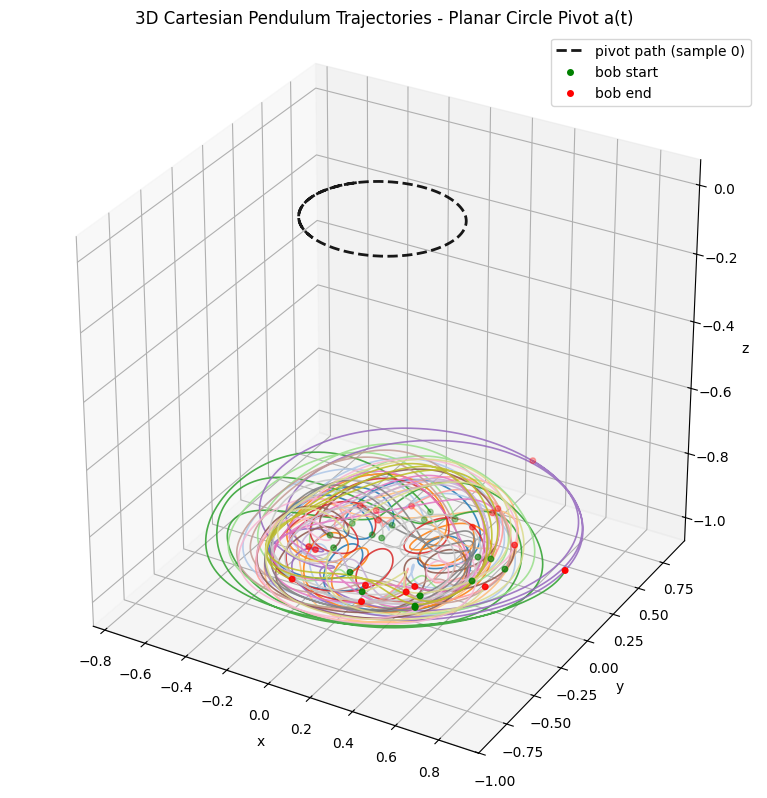

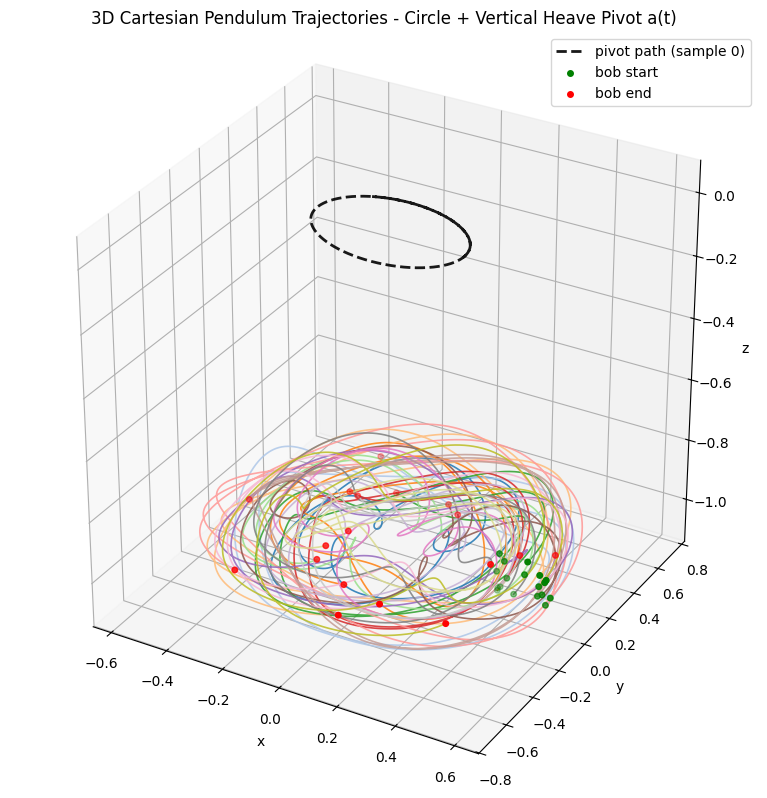

In [27]:
# End plots: same style for each pivot a(t) parameterization
N_family = 120
T_family = 10.0
dt_family = 0.005

X_planar = sample_X_planar_circle(N_family, seed=7)
traj_planar = simulate_cartesian_pendulum_custom(
    params=params,
    t_final=T_family,
    dt=dt_family,
    X=X_planar,
    pivot_eval=lambda t_, X_: pivot_planar_circle_batch(t_, X_, a0=np.array([0.0, 0.0, 0.0])),
)
plot_many_3d_like_you_prefer(
    traj_planar,
    "3D Cartesian Pendulum Trajectories - Planar Circle Pivot a(t)"
)

X_heave = sample_X_circle_heave(N_family, seed=11)
traj_heave = simulate_cartesian_pendulum_custom(
    params=params,
    t_final=T_family,
    dt=dt_family,
    X=X_heave,
    pivot_eval=lambda t_, X_: pivot_circle_heave_batch(t_, X_, a0=np.array([0.0, 0.0, 0.0])),
)
plot_many_3d_like_you_prefer(
    traj_heave,
    "3D Cartesian Pendulum Trajectories - Circle + Vertical Heave Pivot a(t)"
)


In [168]:

def sample_X_shake_pulse(
    n_samples,
    # A sampling
    A_distribution="uniform",          # "uniform" | "gaussian"
    A_range=(0.10, 0.35),              # used if A_distribution == "uniform"
    A_loc=1.0,                         # used if A_distribution == "gaussian"
    A_scale=0.3,                       # used if A_distribution == "gaussian"
    bound_A=None,                      # None or (A_min, A_max), e.g. (0.0, 3.0)

    # omega sampling
    omega_distribution="uniform",      # "uniform" | "gaussian"
    omega_range=(1.0, 3.0),            # used if omega_distribution == "uniform"
    omega_loc=2.0,                     # used if omega_distribution == "gaussian"
    omega_scale=0.5,                   # used if omega_distribution == "gaussian"
    bound_omega=None,                  # None or (w_min, w_max)

    # always uniform
    tau_range=(0.45, 1.2),

    t0=None,
    q=(1.0, 0.0, 0.0),
    a0=(0.0, 0.0, 0.0),
    seed=21,
):
    def _validate_range(name, r):
        if len(r) != 2:
            raise ValueError(f"{name} must be a tuple/list of length 2.")
        lo, hi = float(r[0]), float(r[1])
        if lo > hi:
            raise ValueError(f"{name} lower bound must be <= upper bound.")
        return lo, hi

    def _sample_param(name, distribution, uniform_range, loc, scale, bounds):
        dist = str(distribution).strip().lower()
        if dist == "uniform":
            lo, hi = _validate_range(f"{name}_range", uniform_range)
            x = rng.uniform(lo, hi, size=n_samples)
        elif dist in ("gaussian", "normal"):
            if scale < 0:
                raise ValueError(f"{name}_scale must be >= 0.")
            x = rng.normal(loc=float(loc), scale=float(scale), size=n_samples)
        else:
            raise ValueError(
                f"{name}_distribution must be 'uniform' or 'gaussian', got '{distribution}'."
            )

        if bounds is not None:
            b_lo, b_hi = _validate_range(f"bound_{name}", bounds)
            x = np.clip(x, b_lo, b_hi)
        return x

    rng = np.random.default_rng(seed)

    if n_samples <= 0:
        raise ValueError("n_samples must be > 0.")

    A = _sample_param(
        name="A",
        distribution=A_distribution,
        uniform_range=A_range,
        loc=A_loc,
        scale=A_scale,
        bounds=bound_A,
    )

    omega = _sample_param(
        name="omega",
        distribution=omega_distribution,
        uniform_range=omega_range,
        loc=omega_loc,
        scale=omega_scale,
        bounds=bound_omega,
    )

    tau_lo, tau_hi = _validate_range("tau_range", tau_range)
    tau = rng.uniform(tau_lo, tau_hi, size=n_samples)

    t0_vals = np.full(n_samples, np.nan) if t0 is None else np.full(n_samples, float(t0))

    q = np.asarray(q, dtype=float)
    q_norm = np.linalg.norm(q)
    if q_norm <= 1e-12:
        raise ValueError("q must be non-zero.")
    q = q / q_norm

    a0 = np.asarray(a0, dtype=float)

    q_all = np.tile(q[None, :], (n_samples, 1))
    a0_all = np.tile(a0[None, :], (n_samples, 1))

    # X columns: [A, omega, tau, t0, qx, qy, qz, a0x, a0y, a0z]
    return np.column_stack([A, omega, tau, t0_vals, q_all, a0_all])


def pivot_shake_pulse_batch(t, X):
    X = np.asarray(X, dtype=float)
    A = X[:, 0]
    omega = X[:, 1]
    tau = np.maximum(X[:, 2], 1e-6)
    t0 = X[:, 3].copy()
    q = X[:, 4:7]
    a0 = X[:, 7:10]

    q_norm = np.linalg.norm(q, axis=1, keepdims=True)
    q = q / np.maximum(q_norm, 1e-12)

    # Allow NaN t0 in X: if NaN, set default event center at t=5.0
    t0 = np.where(np.isnan(t0), 5.0, t0)

    s = t - t0
    env = np.exp(-(s**2) / (2.0 * tau**2))
    sin_term = np.sin(omega * s)
    cos_term = np.cos(omega * s)

    amp = A * env * sin_term
    amp_dot = A * env * ((-s / (tau**2)) * sin_term + omega * cos_term)
    amp_ddot = A * env * ((s**2 / (tau**4) - 1.0 / (tau**2) - omega**2) * sin_term - 2.0 * omega * s / (tau**2) * cos_term)

    a = a0 + amp[:, None] * q
    a_dot = amp_dot[:, None] * q
    a_ddot = amp_ddot[:, None] * q
    return a, a_dot, a_ddot


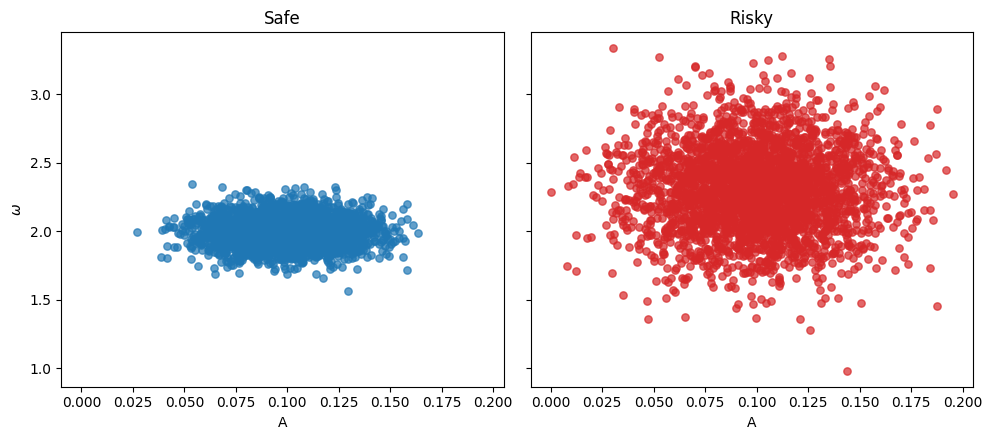

In [218]:
A_safe = X[:, 0]
omega_safe = X[:, 1]

A_risky = X_unsafe[:, 0]
omega_risky = X_unsafe[:, 1]

fig, axs = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)

axs[0].scatter(A_safe, omega_safe, s=28, alpha=0.7, c="tab:blue")
axs[0].set_title("Safe")
axs[0].set_xlabel("A")
axs[0].set_ylabel(r"$\omega$")

axs[1].scatter(A_risky, omega_risky, s=28, alpha=0.7, c="tab:red")
axs[1].set_title("Risky")
axs[1].set_xlabel("A")

plt.tight_layout()
plt.show()



/var/folders/b5/znfvxcd946qb0gfsq9j1td2c0000gn/T/ipykernel_25167/2288135072.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.90])


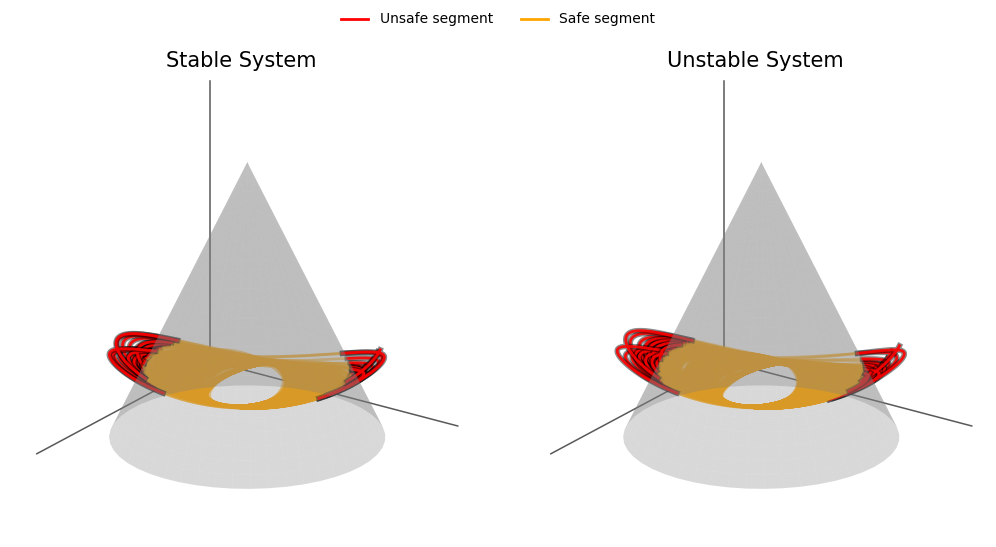

In [221]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def _safety_masks(traj, theta_max_deg):
    r, a = traj["r"], traj["a"]
    d = r - a
    u = d / np.maximum(np.linalg.norm(d, axis=2, keepdims=True), 1e-12)
    cos_th = np.clip(-u[:, :, 2], -1.0, 1.0)
    theta_deg = np.degrees(np.arccos(cos_th))
    safe_mask = theta_deg <= theta_max_deg
    is_stable = np.all(safe_mask, axis=1)
    return safe_mask, is_stable, theta_deg

def _simulate_pulse(A_range, seed=1, omega_range=(1.0, 3.0), tau_range=(0.5, 2.5), N=5, T=10.0, dt=0.005):
    t0 = T / 2.0
    X = sample_X_shake_pulse(
        N,
        A_range=A_range,
        omega_range=omega_range,
        tau_range=tau_range,
        t0=t0,
        q=np.array([1.0, 0.0, 0.0]),
        a0=np.array([0.0, 0.0, 0.0]),
        seed=seed,
    )
    return simulate_cartesian_pendulum_custom(
        params=params, t_final=T, dt=dt, X=X, pivot_eval=pivot_shake_pulse_batch
    )

def _cone_bbox_points(apex, theta_max_deg, cone_height):
    """Points that bound the cone used by _draw_reference_cone."""
    apex = np.asarray(apex, dtype=float)
    th = np.deg2rad(theta_max_deg)
    r = cone_height * np.tan(th)
    z0 = apex[2]
    zb = apex[2] - cone_height
    # apex + 8 points around cone base circle (45 deg increments)
    ang = np.linspace(0, 2*np.pi, 8, endpoint=False)
    base = np.column_stack([apex[0] + r*np.cos(ang), apex[1] + r*np.sin(ang), np.full_like(ang, zb)])
    return np.vstack([apex[None, :], base])

def _draw_back_axes(ax, color="0.35", lw=1.0):
    # choose a rear-bottom corner (works well with azim=-55)
    x0, x1 = ax.get_xlim3d()
    y0, y1 = ax.get_ylim3d()
    z0, z1 = ax.get_zlim3d()

    xb, yb, zb = x0, y1, z0  # back-left-bottom
    ax.plot([x0, x1], [yb, yb], [zb, zb], color=color, lw=lw, zorder=0)  # x-axis (back)
    ax.plot([xb, xb], [y0, y1], [zb, zb], color=color, lw=lw, zorder=0)  # y-axis (back)
    ax.plot([xb, xb], [yb, yb], [z0, z1], color=color, lw=lw, zorder=0)  # z-axis (back)


def plot_safe_vs_risky_3d(
    traj_safe, traj_risky,
    theta_max_deg=35.0, n_plot=5,
    cone_alpha=0.10, cone_color="gray",
    ax_zoom=1.10, panel_wspace=0.01,
    shared_limits=True,
    axis_mode="auto_rect",          # "auto_rect" | "auto_cube"
    axis_scale=(1.0, 1.0, 1.0),     # per-axis zoom for auto mode: (sx, sy, sz)
    axis_pad=(0.02, 0.02, 0.02),    # per-axis padding fraction
    xlim=None, ylim=None, zlim=None # manual override (applies to both subplots)
):
    Ns = min(n_plot, traj_safe["r"].shape[0], traj_risky["r"].shape[0])
    ids = np.arange(Ns)
    # colors = ['orange']*ids#plt.cm.tab10(np.arange(Ns) % 10)
    colors = ['orange'] * Ns
    unsafe_color = 'red'
    lw_line = 2
    safe_mask_s, _, _ = _safety_masks(traj_safe, theta_max_deg)
    safe_mask_r, _, _ = _safety_masks(traj_risky, theta_max_deg)

    fig = plt.figure(figsize=(13.2, 6.0))
    gs = fig.add_gridspec(1, 2, wspace=panel_wspace)
    axs = [fig.add_subplot(gs[0, 0], projection="3d"),
           fig.add_subplot(gs[0, 1], projection="3d")]
    
    def _cone_bbox_points(apex, theta_max_deg, cone_height):
        apex = np.asarray(apex, dtype=float)
        th = np.deg2rad(theta_max_deg)
        r = cone_height * np.tan(th)
        zb = apex[2] - cone_height
        ang = np.linspace(0, 2*np.pi, 8, endpoint=False)
        base = np.column_stack([
            apex[0] + r*np.cos(ang),
            apex[1] + r*np.sin(ang),
            np.full_like(ang, zb)
        ])
        return np.vstack([apex[None, :], base])

    def draw(ax, traj, safe_mask, title):
        
        r, a = traj["r"], traj["a"]
        d = r - a
        ell_est = float(np.median(np.linalg.norm(d, axis=2)))
        apex = a[0, 0]
        cone_h = 1.2 * ell_est

        _draw_reference_cone(ax, apex=apex, theta_max_deg=theta_max_deg,
                             cone_height=cone_h, color=cone_color, alpha=cone_alpha)

        bad_count = 0
        for j, i in enumerate(ids):
            ax.plot(r[i, :, 0], r[i, :, 1], r[i, :, 2], color=colors[j], lw=lw_line, alpha=0.50)
            bad = ~safe_mask[i]
            if bad.any():
                bad_count += 1
                x = np.ma.masked_where(~bad, r[i, :, 0])
                y = np.ma.masked_where(~bad, r[i, :, 1])
                z = np.ma.masked_where(~bad, r[i, :, 2])
                ax.plot(x, y, z, color="black", lw=4.0, alpha=0.50)
                ax.plot(x, y, z, color=unsafe_color, lw=lw_line, alpha=0.55)

            # ax.scatter(r[i, 0, 0], r[i, 0, 1], r[i, 0, 2], s=20, c=[colors[j]])
            # ax.scatter(r[i, -1, 0], r[i, -1, 1], r[i, -1, 2], s=22, c=[colors[j]])

        # ax.plot(a[0, :, 0], a[0, :, 1], a[0, :, 2], "k--", lw=1.8, alpha=0.9)
        # ax.set_title(f"{title}\nunsafe: {bad_count}/{Ns}", fontsize=15)
        ax.set_title(f"{title}", fontsize=15)
        # ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
        ax.view_init(elev=22, azim=-55)
        ax.set_box_aspect((1, 1, 1), zoom=ax_zoom)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])
        ax.grid(False)
        ax.set_axis_off()
        _draw_back_axes(ax)
        # ax.set_facecolor("white")
        # for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        #     axis.pane.fill = False
        #     axis.pane.set_edgecolor((1, 1, 1, 0))
        pts = np.concatenate([
            r[ids].reshape(-1, 3),
            a[:1].reshape(-1, 3),
            _cone_bbox_points(apex, theta_max_deg, cone_h),
        ], axis=0)
        return pts

    pts_s = draw(axs[0], traj_safe, safe_mask_s, "Stable System")
    pts_r = draw(axs[1], traj_risky, safe_mask_r, "Unstable System")

    def _auto_limits(pts):
        mn, mx = pts.min(axis=0), pts.max(axis=0)
        c = 0.5 * (mn + mx)
        span = (mx - mn).astype(float)

        if axis_mode == "auto_cube":
            span[:] = span.max()

        span *= np.asarray(axis_scale, dtype=float)
        half = 0.5 * span * (1.0 + np.asarray(axis_pad, dtype=float))

        return (c[0] - half[0], c[0] + half[0]), \
               (c[1] - half[1], c[1] + half[1]), \
               (c[2] - half[2], c[2] + half[2])

    if shared_limits:
        pts_all = np.concatenate([pts_s, pts_r], axis=0)
        ax_x, ax_y, ax_z = _auto_limits(pts_all)
        ax_x = xlim if xlim is not None else ax_x
        ax_y = ylim if ylim is not None else ax_y
        ax_z = zlim if zlim is not None else ax_z
        for ax in axs:
            ax.set_xlim(*ax_x); ax.set_ylim(*ax_y); ax.set_zlim(*ax_z)
    else:
        for ax, pts in zip(axs, [pts_s, pts_r]):
            ax_x, ax_y, ax_z = _auto_limits(pts)
            ax.set_xlim(*(xlim if xlim is not None else ax_x))
            ax.set_ylim(*(ylim if ylim is not None else ax_y))
            ax.set_zlim(*(zlim if zlim is not None else ax_z))

    # handles = [Line2D([0], [0], color=colors[j], lw=2, label=f"traj {j}") for j in range(Ns)]
    handles = [Line2D([0], [0], color=unsafe_color, lw=lw_line, label="Unsafe segment"),
               Line2D([0], [0], color=colors[0], lw=lw_line, label="Safe segment"),]
                #Line2D([0], [0], color="k", lw=1.8, ls="--", label="pivot path")]
    fig.legend(handles=handles, loc="upper center", ncol=min(6, Ns + 2), frameon=False)

    plt.tight_layout(rect=[0, 0, 3, 0.90])
    plt.show()

# Example:
num_traj = 300
t0 = T / 2.0
X = sample_X_shake_pulse(n_samples=num_traj,A_distribution='gaussian', A_loc=0.1, A_scale=0.01, bound_A=(0.0, 0.2), 
                         omega_distribution='gaussian', omega_loc=1.0, omega_scale=0.02, bound_omega=(0, 5),
                         seed=42,t0 = t0)

traj_safe = simulate_cartesian_pendulum_custom(
        params=params, t_final=T, dt=dt, X=X, pivot_eval=pivot_shake_pulse_batch
    )

# X = sample_X_shake_pulse(A_distribution='gaussian')
# traj_safe  = _simulate_pulse(A_range=(0.01, 0.08),omega_range=(1.0, 3.0),  tau_range=(0.5, 2.5),seed=23, N=num_traj)
# # traj_risky = _simulate_pulse(A_range=(0.1, 0.2),omega_range=(1.0, 3.0),  tau_range=(0.5, 2.5), seed=24, N=num_traj)

X_safe = sample_X_shake_pulse(n_samples=num_traj,A_distribution='gaussian', A_loc=0.1, A_scale=0.02, bound_A=(0.0, 0.2), 
                         omega_distribution='gaussian', omega_loc=2, omega_scale=0.2, bound_omega=(0, 5),
                         seed=42,t0 = t0)

traj_still_safe = simulate_cartesian_pendulum_custom(
        params=params, t_final=T, dt=dt, X=X_unsafe, pivot_eval=pivot_shake_pulse_batch
    )




X_unsafe = sample_X_shake_pulse(n_samples=num_traj,A_distribution='gaussian', A_loc=0.1, A_scale=0.03, bound_A=(0.0, 0.2), 
                         omega_distribution='gaussian', omega_loc=2, omega_scale=0.5, bound_omega=(0, 5),
                         seed=42,t0 = t0)

traj_risky = simulate_cartesian_pendulum_custom(
        params=params, t_final=T, dt=dt, X=X_unsafe, pivot_eval=pivot_shake_pulse_batch
    )


# plot_safe_vs_risky_3d(traj_safe, traj_risky,
#                       shared_limits=True,
#                       theta_max_deg=35,
#                       n_plot=num_traj,
#                       cone_alpha = 0.2,
#                       axis_mode="auto_rect",    
#                       axis_scale=(1.0, 1.0, 1),
#                       axis_pad=(0.02, 0.02, 0.00))   # per-axis padding fraction)

plot_safe_vs_risky_d3d(
    traj_still_safe, traj_risky,
    theta_max_deg=25, n_plot=50,
    cone_alpha=0.3, shared_limits=True
)

True True
True True
True True


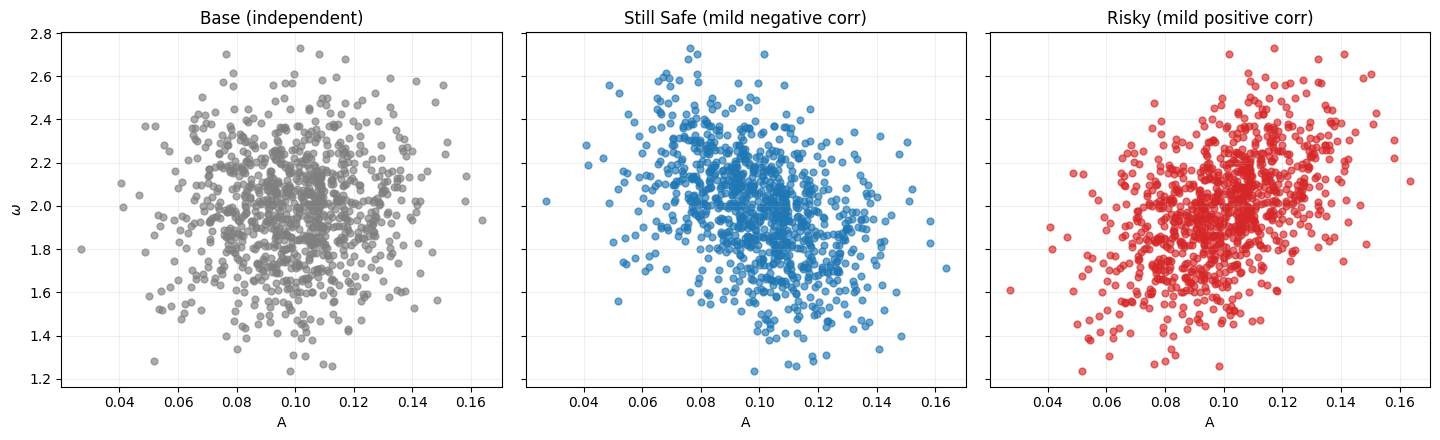

In [227]:
import numpy as np

def build_X_from_arrays(A, omega, tau, t0, q=(1,0,0), a0=(0,0,0)):
    n = len(A)
    q = np.asarray(q, float); q = q / np.linalg.norm(q)
    a0 = np.asarray(a0, float)

    t0_vals = np.full(n, np.nan) if t0 is None else np.full(n, float(t0))
    q_all = np.tile(q[None, :], (n, 1))
    a0_all = np.tile(a0[None, :], (n, 1))
    return np.column_stack([A, omega, tau, t0_vals, q_all, a0_all])

def make_safe_risky_same_support(
    n_samples, seed=42, t0=5.0,
    A_loc=0.10, A_scale=0.025, A_bound=(0.0, 0.2),
    w_loc=2.0, w_scale=0.35, w_bound=(0.0, 5.0),
    tau_range=(0.6, 1.6),
):
    rng = np.random.default_rng(seed)

    # 1) sample ONE base pool (shared support + shared marginals)
    A = np.clip(rng.normal(A_loc, A_scale, n_samples), *A_bound)
    w = np.clip(rng.normal(w_loc, w_scale, n_samples), *w_bound)
    tau = rng.uniform(*tau_range, n_samples)

    # 2) re-pair A and w:
    # risky: high A with high w (positive rank correlation)
    # safe : high A with low  w (negative rank correlation)
    A_sorted = np.sort(A)
    w_sorted = np.sort(w)

    A_risky = A_sorted.copy()
    w_risky = w_sorted.copy()

    A_safe = A_sorted.copy()
    w_safe = w_sorted[::-1].copy()

    # 3) shuffle sample order so points look like clouds, not ordered curves
    p_safe = rng.permutation(n_samples)
    p_risky = rng.permutation(n_samples)

    A_safe, w_safe = A_safe[p_safe], w_safe[p_safe]
    A_risky, w_risky = A_risky[p_risky], w_risky[p_risky]

    # keep tau marginal same too
    tau_safe = np.sort(tau)[p_safe]
    tau_risky = np.sort(tau)[p_risky]

    X_safe = build_X_from_arrays(A_safe, w_safe, tau_safe, t0=t0)
    X_risky = build_X_from_arrays(A_risky, w_risky, tau_risky, t0=t0)

    return X_safe, X_risky

import numpy as np

def impose_rank_dependence(A, omega_values, mode="indep", strength=0.25, seed=0):
    """
    Reorders omega_values only (same exact values/support), changing dependence with A.
    mode: "indep" | "neg" | "pos"
    strength in [0,1]: larger => stronger dependence
    """
    rng = np.random.default_rng(seed)
    n = len(A)

    # rank-normalized A
    r = np.argsort(np.argsort(A))
    z = (r + 0.5) / n
    z = (z - z.mean()) / (z.std() + 1e-12)

    eps = rng.normal(size=n)
    if mode == "indep":
        score = eps
    elif mode == "pos":
        score = np.sqrt(strength) * z + np.sqrt(1 - strength) * eps
    elif mode == "neg":
        score = -np.sqrt(strength) * z + np.sqrt(1 - strength) * eps
    else:
        raise ValueError("mode must be 'indep', 'neg', or 'pos'")

    # assign sorted omega by score order (preserves omega marginal exactly)
    vals = np.sort(omega_values)
    order = np.argsort(score)
    omega_new = np.empty_like(omega_values)
    omega_new[order] = vals
    return omega_new


def build_X_with_dependence(
    n_samples, t0, seed=42,
    A_loc=0.10, A_scale=0.02, bound_A=(0.0, 0.2),
    w_loc=2.0, w_scale=0.25, bound_w=(0.0, 5.0),
    tau_range=(0.5, 2.5),
    dep_mode="indep", dep_strength=0.25,
    q=(1.0, 0.0, 0.0), a0=(0.0, 0.0, 0.0),
):
    rng = np.random.default_rng(seed)

    A = np.clip(rng.normal(A_loc, A_scale, n_samples), *bound_A)
    omega_base = np.clip(rng.normal(w_loc, w_scale, n_samples), *bound_w)
    omega = impose_rank_dependence(A, omega_base, mode=dep_mode, strength=dep_strength, seed=seed+1)

    tau = rng.uniform(*tau_range, n_samples)
    t0_vals = np.full(n_samples, float(t0))

    q = np.asarray(q, float); q = q / np.linalg.norm(q)
    a0 = np.asarray(a0, float)
    q_all = np.tile(q[None, :], (n_samples, 1))
    a0_all = np.tile(a0[None, :], (n_samples, 1))

    return np.column_stack([A, omega, tau, t0_vals, q_all, a0_all])

# ---- usage ----
# X, X_unsafe = make_safe_risky_same_support(
#     n_samples=num_traj, seed=42, t0=t0,
#     A_loc=0.10, A_scale=0.025, A_bound=(0.0, 0.2),
#     w_loc=2.0, w_scale=0.35, w_bound=(0.0, 5.0),
# )
num_traj = 1000
X_base  = build_X_with_dependence(num_traj, t0, seed=42, dep_mode="indep", dep_strength=0.0)
X_safe  = build_X_with_dependence(num_traj, t0, seed=42, dep_mode="neg",   dep_strength=0.2)
X_risky = build_X_with_dependence(num_traj, t0, seed=42, dep_mode="pos",   dep_strength=0.2)


traj_safe = simulate_cartesian_pendulum_custom(
    params=params, t_final=T, dt=dt, X=X_base, pivot_eval=pivot_shake_pulse_batch
)
traj_still_safe = simulate_cartesian_pendulum_custom(
    params=params, t_final=T, dt=dt, X=X_safe, pivot_eval=pivot_shake_pulse_batch
)
traj_risky = simulate_cartesian_pendulum_custom(
    params=params, t_final=T, dt=dt, X=X_risky, pivot_eval=pivot_shake_pulse_batch
)

A_base,  w_base  = X_base[:, 0],  X_base[:, 1]
A_safe,  w_safe  = X_safe[:, 0],  X_safe[:, 1]
A_risky, w_risky = X_risky[:, 0], X_risky[:, 1]

# optional sanity checks: same marginals across all 3
print(np.allclose(np.sort(X_base[:, 0]), np.sort(X_safe[:, 0])), np.allclose(np.sort(X_base[:, 0]), np.sort(X_risky[:, 0])))  # A
print(np.allclose(np.sort(X_base[:, 1]), np.sort(X_safe[:, 1])), np.allclose(np.sort(X_base[:, 1]), np.sort(X_risky[:, 1])))  # omega
print(np.allclose(np.sort(X_base[:, 2]), np.sort(X_safe[:, 2])), np.allclose(np.sort(X_base[:, 2]), np.sort(X_risky[:, 2])))  # tau

fig, axs = plt.subplots(1, 3, figsize=(14.5, 4.5), sharex=True, sharey=True)

axs[0].scatter(A_base, w_base, s=24, alpha=0.65, c="tab:gray")
axs[0].set_title("Base (independent)")
axs[0].set_xlabel("A")
axs[0].set_ylabel(r"$\omega$")

axs[1].scatter(A_safe, w_safe, s=24, alpha=0.65, c="tab:blue")
axs[1].set_title("Still Safe (mild negative corr)")
axs[1].set_xlabel("A")

axs[2].scatter(A_risky, w_risky, s=24, alpha=0.65, c="tab:red")
axs[2].set_title("Risky (mild positive corr)")
axs[2].set_xlabel("A")

for ax in axs:
    ax.grid(alpha=0.25, lw=0.6)

plt.tight_layout()
plt.show()


/var/folders/b5/znfvxcd946qb0gfsq9j1td2c0000gn/T/ipykernel_25167/3251754548.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.90])


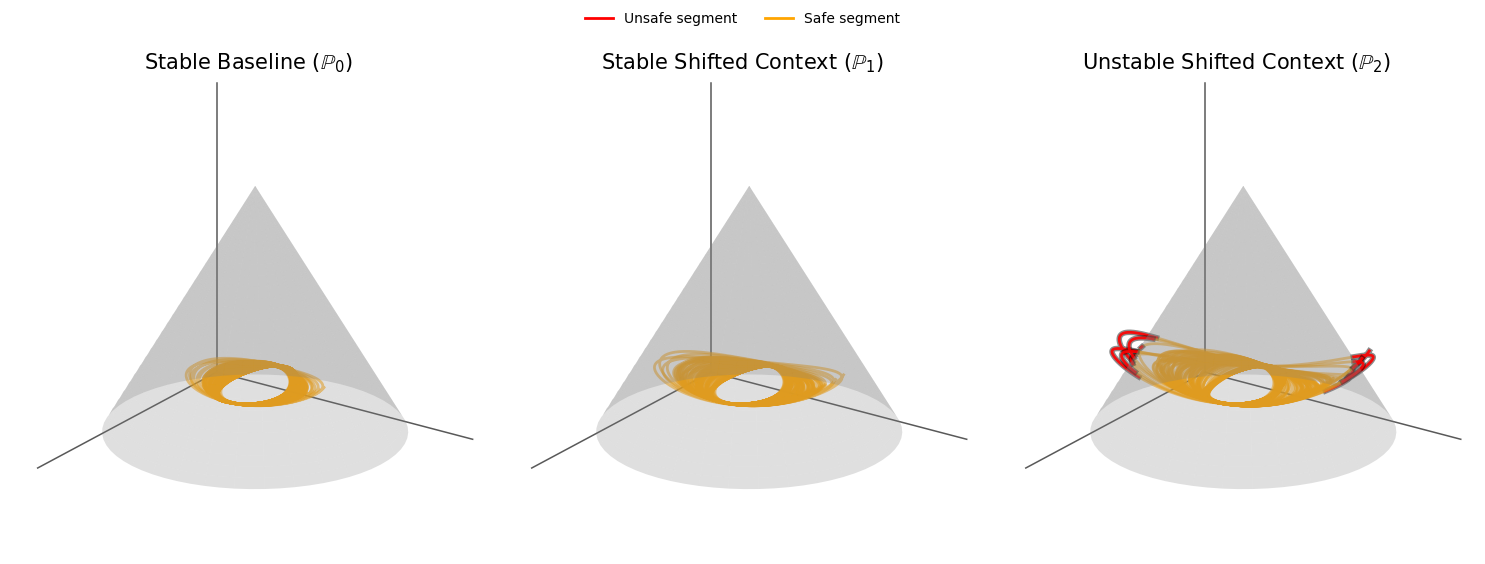

In [349]:

def plot_three_regimes_d3d(
    traj_base, traj_still_safe, traj_risky,
    titles=(r"Base System ($\mathbb{P}_0$)", "Still Safe System", "Unstable System"),
    theta_max_deg=35.0, n_plot=5,
    cone_alpha=0.10, cone_color="gray",
    ax_zoom=1.10, panel_wspace=0.02,
    shared_limits=True,
    axis_mode="auto_cube",          # "auto_rect" | "auto_cube"
    axis_scale=(1.0, 1.0, 1.0),
    axis_pad=(0.02, 0.02, 0.02),
    xlim=None, ylim=None, zlim=None
):
    def _safety_masks_from_d(d, theta_max_deg):
        d_norm = np.linalg.norm(d, axis=2, keepdims=True)
        u = d / np.maximum(d_norm, 1e-12)
        safe_mask = (-u[:, :, 2]) >= np.cos(np.deg2rad(theta_max_deg))
        is_stable = np.all(safe_mask, axis=1)
        return safe_mask, is_stable

    def _draw_reference_cone_local(ax, apex=np.zeros(3), theta_max_deg=35.0, cone_height=1.2, color="gray", alpha=0.12):
        theta = np.deg2rad(theta_max_deg)
        phi = np.linspace(0.0, 2.0 * np.pi, 64)
        h = np.linspace(0.0, cone_height, 28)
        P, H = np.meshgrid(phi, h)
        R = H * np.tan(theta)
        Xc = apex[0] + R * np.cos(P)
        Yc = apex[1] + R * np.sin(P)
        Zc = apex[2] - H
        ax.plot_surface(Xc, Yc, Zc, color=color, alpha=alpha, linewidth=0, shade=False)

    def _cone_bbox_points(apex, theta_max_deg, cone_height):
        apex = np.asarray(apex, dtype=float)
        th = np.deg2rad(theta_max_deg)
        r = cone_height * np.tan(th)
        zb = apex[2] - cone_height
        ang = np.linspace(0, 2*np.pi, 12, endpoint=False)
        base = np.column_stack([
            apex[0] + r*np.cos(ang),
            apex[1] + r*np.sin(ang),
            np.full_like(ang, zb)
        ])
        return np.vstack([apex[None, :], base])

    def _draw_back_axes(ax, color="0.35", lw=1.1):
        x0, x1 = ax.get_xlim3d()
        y0, y1 = ax.get_ylim3d()
        z0, z1 = ax.get_zlim3d()
        xb, yb, zb = x0, y1, z0
        ax.plot([x0, x1], [yb, yb], [zb, zb], color=color, lw=lw, zorder=0)
        ax.plot([xb, xb], [y0, y1], [zb, zb], color=color, lw=lw, zorder=0)
        ax.plot([xb, xb], [yb, yb], [z0, z1], color=color, lw=lw, zorder=0)

    trajs = [traj_base, traj_still_safe, traj_risky]
    Ns = min(n_plot, *(tr["r"].shape[0] for tr in trajs))
    ids = np.arange(Ns)

    colors = ["orange"] * Ns
    unsafe_color = "red"
    lw_line = 2.0

    d_all = [tr["r"] - tr["a"] for tr in trajs]
    masks_all = [_safety_masks_from_d(d, theta_max_deg)[0] for d in d_all]

    fig = plt.figure(figsize=(19, 6.2))
    gs = fig.add_gridspec(1, 3, wspace=panel_wspace)
    axs = [fig.add_subplot(gs[0, i], projection="3d") for i in range(3)]

    def draw(ax, d, safe_mask, title):
        ell_est = float(np.median(np.linalg.norm(d, axis=2)))
        apex = np.zeros(3)
        cone_h = 1.2 * ell_est

        _draw_reference_cone_local(
            ax, apex=apex, theta_max_deg=theta_max_deg,
            cone_height=cone_h, color=cone_color, alpha=cone_alpha
        )

        for j, i in enumerate(ids):
            good = safe_mask[i]
            bad = ~good

            xg = np.ma.masked_where(~good, d[i, :, 0])
            yg = np.ma.masked_where(~good, d[i, :, 1])
            zg = np.ma.masked_where(~good, d[i, :, 2])
            ax.plot(xg, yg, zg, color=colors[j], lw=lw_line, alpha=0.55)

            if bad.any():
                xb = np.ma.masked_where(~bad, d[i, :, 0])
                yb = np.ma.masked_where(~bad, d[i, :, 1])
                zb = np.ma.masked_where(~bad, d[i, :, 2])
                ax.plot(xb, yb, zb, color="black", lw=4.0, alpha=0.45)
                ax.plot(xb, yb, zb, color=unsafe_color, lw=lw_line, alpha=0.9)

        ax.set_title(title, fontsize=15)
        ax.set_proj_type("ortho")
        ax.view_init(elev=22, azim=-55)
        ax.set_box_aspect((1, 1, 1), zoom=ax_zoom)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
        ax.grid(False)
        ax.set_axis_off()

        return np.concatenate([
            d[ids].reshape(-1, 3),
            _cone_bbox_points(apex, theta_max_deg, cone_h),
        ], axis=0)

    pts_list = [draw(ax, d, m, t) for ax, d, m, t in zip(axs, d_all, masks_all, titles)]

    def _auto_limits(pts):
        mn, mx = pts.min(axis=0), pts.max(axis=0)
        c = 0.5 * (mn + mx)
        span = (mx - mn).astype(float)
        if axis_mode == "auto_cube":
            span[:] = span.max()
        span *= np.asarray(axis_scale, dtype=float)
        half = 0.5 * span * (1.0 + np.asarray(axis_pad, dtype=float))
        return (c[0] - half[0], c[0] + half[0]), \
               (c[1] - half[1], c[1] + half[1]), \
               (c[2] - half[2], c[2] + half[2])

    if shared_limits:
        pts_all = np.concatenate(pts_list, axis=0)
        ax_x, ax_y, ax_z = _auto_limits(pts_all)
        ax_x = xlim if xlim is not None else ax_x
        ax_y = ylim if ylim is not None else ax_y
        ax_z = zlim if zlim is not None else ax_z
        for ax in axs:
            ax.set_xlim(*ax_x); ax.set_ylim(*ax_y); ax.set_zlim(*ax_z)
    else:
        for ax, pts in zip(axs, pts_list):
            ax_x, ax_y, ax_z = _auto_limits(pts)
            ax.set_xlim(*(xlim if xlim is not None else ax_x))
            ax.set_ylim(*(ylim if ylim is not None else ax_y))
            ax.set_zlim(*(zlim if zlim is not None else ax_z))

    for ax in axs:
        _draw_back_axes(ax)

    handles = [
        Line2D([0], [0], color=unsafe_color, lw=lw_line, label="Unsafe segment"),
        Line2D([0], [0], color=colors[0], lw=lw_line, label="Safe segment"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

num_traj = 1500
w_loc=1.7; w_scale = 0.4
A_loc = 0.05; A_scale = 0.03
X_base  = build_X_with_dependence(num_traj, t0, seed=42, dep_mode="indep", dep_strength=0.,
                                  A_loc=A_loc,A_scale=A_scale,bound_A=(0.0, 0.3),
                                  w_loc=w_loc,w_scale=w_scale,bound_w=(0.0, 5.0),
                                  tau_range=(1,1.01))
X_safe  = build_X_with_dependence(num_traj, t0, seed=42, dep_mode="indep",   dep_strength=0.0,
                                  A_loc=A_loc,A_scale=A_scale,bound_A=(0.0, 0.3),
                                  w_loc=w_loc+0.7,w_scale=w_scale+0.4,bound_w=(0.0, 5.0),
                                  tau_range=(1,1.01))
X_risky = build_X_with_dependence(num_traj, t0, seed=42, dep_mode="indep",   dep_strength=0,
                                  A_loc=A_loc+0.1,A_scale=A_scale+0.04,bound_A=(0.0, 0.3),
                                  w_loc=w_loc,w_scale=w_scale,bound_w=(0.0, 5.0),
                                  tau_range=(1,1.01))


traj_safe = simulate_cartesian_pendulum_custom(
    params=params, t_final=T, dt=dt, X=X_base, pivot_eval=pivot_shake_pulse_batch
)
traj_still_safe = simulate_cartesian_pendulum_custom(
    params=params, t_final=T, dt=dt, X=X_safe, pivot_eval=pivot_shake_pulse_batch
)
traj_risky = simulate_cartesian_pendulum_custom(
    params=params, t_final=T, dt=dt, X=X_risky, pivot_eval=pivot_shake_pulse_batch
)

A_base,  w_base  = X_base[:, 0],  X_base[:, 1]
A_safe,  w_safe  = X_safe[:, 0],  X_safe[:, 1]
A_risky, w_risky = X_risky[:, 0], X_risky[:, 1]

r"Stable Baseline ($\mathbb{P}_0$)"

plot_three_regimes_d3d(
    traj_safe, traj_still_safe, traj_risky,
    titles=(r"Stable Baseline ($\mathbb{P}_0$)", r"Stable Shifted Context ($\mathbb{P}_1$)", r"Unstable Shifted Context ($\mathbb{P}_2$)"),
    theta_max_deg=30, n_plot=30, cone_alpha=0.25
)

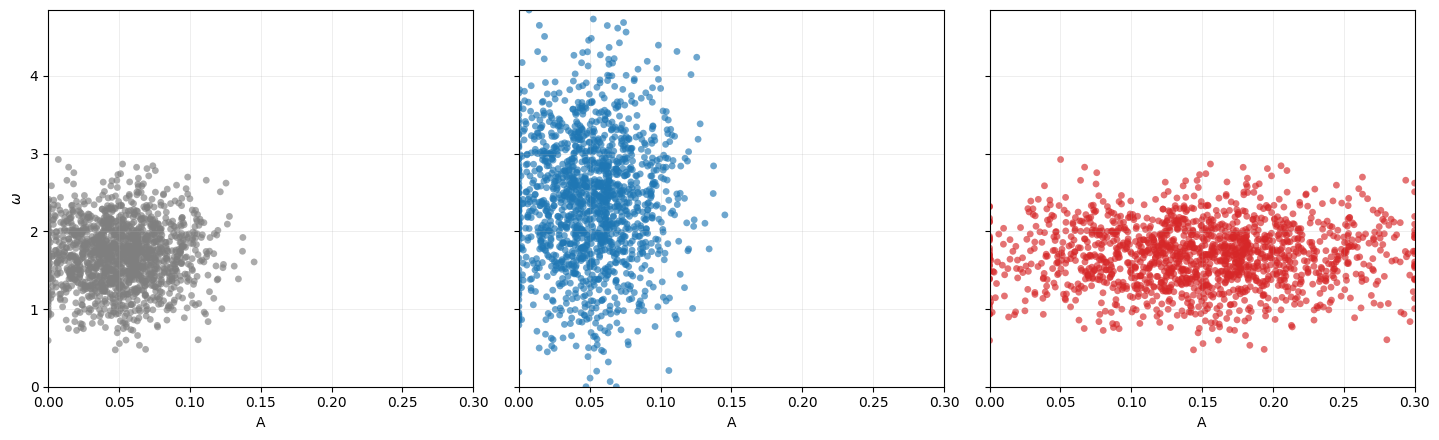

In [350]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_three_joint_with_marginals(
    A_base, w_base,
    A_safe, w_safe,
    A_risky, w_risky,
    bins=35,
    show_marginals=True,   # <- set False for joint-only
    point_size=24,
    alpha=0.65,
):
    panels = [
        (A_base,  w_base,  "tab:gray", "Baseline (Stable)"),
        (A_safe,  w_safe,  "tab:blue", "Safe Shift (Stavle)"),
        (A_risky, w_risky, "tab:red",  "Risky (mild positive corr)"),
    ]

    A_all = np.concatenate([A_base, A_safe, A_risky])
    w_all = np.concatenate([w_base, w_safe, w_risky])
    A_lim = (A_all.min(), A_all.max())
    w_lim = (w_all.min(), w_all.max())

    fig, axs = plt.subplots(1, 3, figsize=(14.5, 4.5), sharex=True, sharey=True)

    for i, (A, w, color, title) in enumerate(panels):
        ax = axs[i]
        ax.scatter(A, w, s=point_size, alpha=alpha, c=color, edgecolors="none")
        ax.set_title(title)
        ax.set_xlabel("A")
        if i == 0:
            ax.set_ylabel(r"$\omega$")
        ax.set_xlim(A_lim)
        ax.set_ylim(w_lim)
        ax.grid(alpha=0.25, lw=0.6)
        ax.set_title("")
        if show_marginals:
            div = make_axes_locatable(ax)
            ax_top = div.append_axes("top", size="24%", pad=0.05, sharex=ax)
            ax_right = div.append_axes("right", size="24%", pad=0.05, sharey=ax)

            ax_top.hist(A, bins=bins, range=A_lim, density=True, color=color, alpha=0.35)
            ax_right.hist(w, bins=bins, range=w_lim, density=True,
                          orientation="horizontal", color=color, alpha=0.35)

            # base reference marginals
            ax_top.hist(A_base, bins=bins, range=A_lim, density=True,
                        histtype="step", color="k", lw=1.2, linestyle="--")
            ax_right.hist(w_base, bins=bins, range=w_lim, density=True,
                          orientation="horizontal", histtype="step",
                          color="k", lw=1.2, linestyle="--")

            ax_top.tick_params(axis="x", labelbottom=False)
            ax_top.set_yticks([])
            ax_right.tick_params(axis="y", labelleft=False)
            ax_right.set_xticks([])

    plt.tight_layout()
    plt.show()

# call
# plot_three_joint_with_marginals(
#     A_base, w_base,
#     A_safe, w_safe,
#     A_risky, w_risky
# )
plot_three_joint_with_marginals(A_base, w_base, A_safe, w_safe, A_risky, w_risky, show_marginals=False)



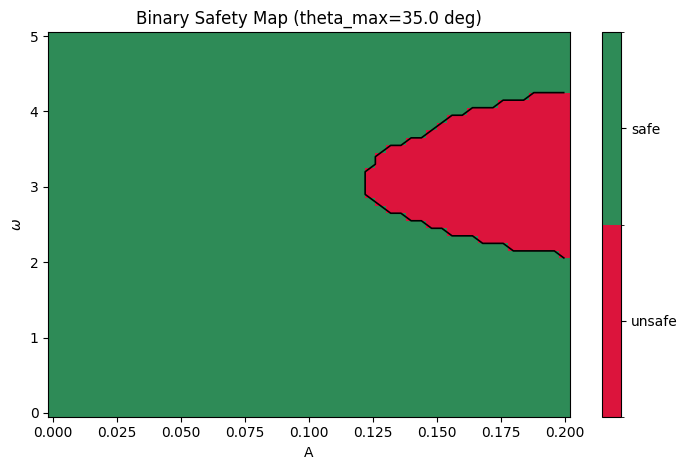

In [270]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def sweep_A_omega_binary_safety(
    params,
    pivot_eval,                      # e.g. pivot_shake_pulse_batch
    t_final=10.0,
    dt=0.005,
    A_range=(0.0, 0.2),
    omega_range=(0.0, 5.0),
    n_A=61,
    n_omega=101,
    tau=1.0,
    t0=5.0,
    q=(1.0, 0.0, 0.0),
    a0=(0.0, 0.0, 0.0),
    theta_max_deg=35.0,
    project_each_step=True,
    n0=np.array([0.15, 0.0, -0.9887]),
    rel_v0=np.array([0.0, 0.8, 0.0]),
    plot=True,
):
    # Grid
    A_vals = np.linspace(*A_range, n_A)
    omega_vals = np.linspace(*omega_range, n_omega)
    AA, WW = np.meshgrid(A_vals, omega_vals, indexing="xy")   # shape (n_omega, n_A)

    # Build X for all grid points (batch simulation)
    N = AA.size
    q = np.asarray(q, dtype=float); q = q / np.linalg.norm(q)
    a0 = np.asarray(a0, dtype=float)

    X = np.column_stack([
        AA.ravel(),                        # A
        WW.ravel(),                        # omega
        np.full(N, float(tau)),            # tau
        np.full(N, float(t0)),             # t0
        np.tile(q[None, :], (N, 1)),       # qx,qy,qz
        np.tile(a0[None, :], (N, 1)),      # a0x,a0y,a0z
    ])

    traj = simulate_cartesian_pendulum_custom(
        params=params,
        t_final=t_final,
        dt=dt,
        X=X,
        pivot_eval=pivot_eval,
        n0=n0,
        rel_v0=rel_v0,
        project_each_step=project_each_step,
    )

    # Safety: all time steps must satisfy theta <= theta_max
    d = traj["r"] - traj["a"]  # relative rod vector
    u = d / np.maximum(np.linalg.norm(d, axis=2, keepdims=True), 1e-12)
    safe_mask_time = (-u[:, :, 2]) >= np.cos(np.deg2rad(theta_max_deg))
    safe_label = np.all(safe_mask_time, axis=1).astype(int)   # 1 safe, 0 unsafe

    Z = safe_label.reshape(n_omega, n_A)

    if plot:
        cmap = ListedColormap(["crimson", "seagreen"])  # 0 unsafe, 1 safe
        norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

        fig, ax = plt.subplots(figsize=(7.2, 4.8))
        m = ax.pcolormesh(A_vals, omega_vals, Z, shading="nearest", cmap=cmap, norm=norm)
        ax.contour(AA, WW, Z, levels=[0.5], colors="k", linewidths=1.2)  # boundary
        cbar = fig.colorbar(m, ax=ax, ticks=[0, 1])
        cbar.ax.set_yticklabels(["unsafe", "safe"])

        ax.set_xlabel("A")
        ax.set_ylabel(r"$\omega$")
        ax.set_title(f"Binary Safety Map (theta_max={theta_max_deg:.1f} deg)")
        plt.tight_layout()
        plt.show()

    return A_vals, omega_vals, Z, traj
A_vals, omega_vals, Z, traj_grid = sweep_A_omega_binary_safety(
    params=params,
    pivot_eval=pivot_shake_pulse_batch,
    A_range=(0.0, 0.2),
    omega_range=(0.0, 5.0),
    n_A=51,
    n_omega=51,
    tau=1.0,
    t0=5.0,
    theta_max_deg=35.0,
)


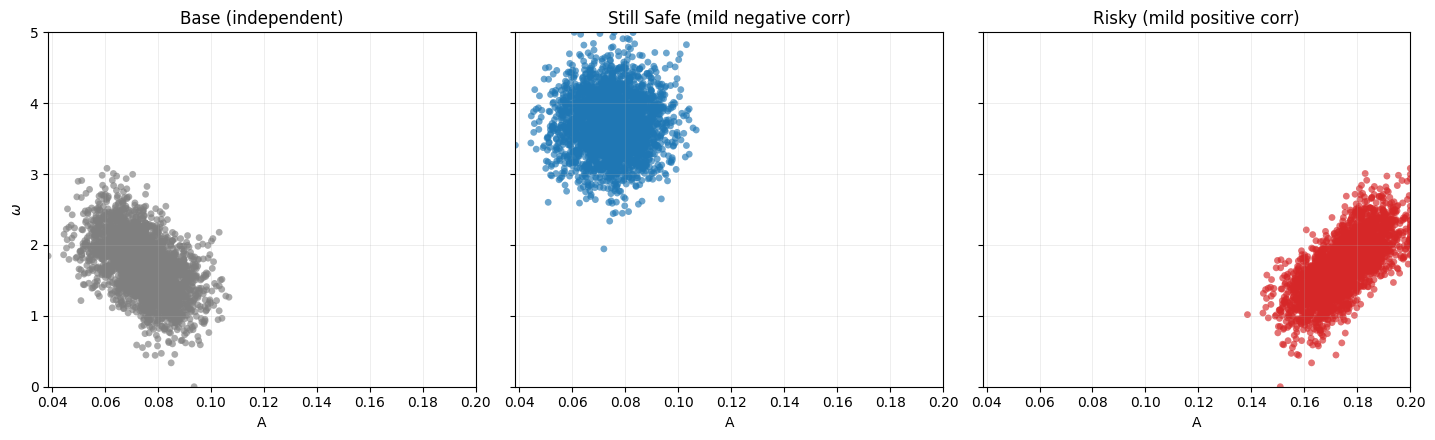

In [198]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def _draw_reference_cone_local(ax, apex=np.zeros(3), theta_max_deg=35.0, cone_height=1.2,
                               color="gray", alpha=0.06):
    theta = np.deg2rad(theta_max_deg)
    phi = np.linspace(0.0, 2.0*np.pi, 96)
    h = np.linspace(0.0, cone_height, 32)
    P, H = np.meshgrid(phi, h)
    R = H * np.tan(theta)

    Xc = apex[0] + R*np.cos(P)
    Yc = apex[1] + R*np.sin(P)
    Zc = apex[2] - H

    ax.plot_surface(Xc, Yc, Zc, color=color, alpha=alpha, linewidth=0, shade=False)

    # cone rim (very important visually)
    rb = cone_height * np.tan(theta)
    xr = apex[0] + rb*np.cos(phi)
    yr = apex[1] + rb*np.sin(phi)
    zr = np.full_like(phi, apex[2] - cone_height)
    ax.plot(xr, yr, zr, color="0.35", lw=1.2, alpha=0.9)

    # a few generator lines
    for ang in np.deg2rad([0, 60, 120, 180, 240, 300]):
        ax.plot([apex[0], apex[0] + rb*np.cos(ang)],
                [apex[1], apex[1] + rb*np.sin(ang)],
                [apex[2], apex[2] - cone_height],
                color="0.45", lw=0.8, alpha=0.8)

def plot_safe_vs_risky_d3d(
    traj_safe, traj_risky,
    theta_max_deg=35.0, n_plot=5,
    cone_alpha=0.10, cone_color="gray",
    ax_zoom=1.10, panel_wspace=0.01,
    shared_limits=True,
    axis_mode="auto_cube",          # "auto_rect" | "auto_cube"
    axis_scale=(1.0, 1.0, 1.0),
    axis_pad=(0.02, 0.02, 0.02),
    xlim=None, ylim=None, zlim=None
):
    """
    Plot in pivot-relative frame d(t)=r(t)-a(t), so cone test/visualization are consistent.
    """

    def _safety_masks_from_d(d, theta_max_deg):
        d_norm = np.linalg.norm(d, axis=2, keepdims=True)
        u = d / np.maximum(d_norm, 1e-12)
        safe_mask = (-u[:, :, 2]) >= np.cos(np.deg2rad(theta_max_deg))
        is_stable = np.all(safe_mask, axis=1)
        return safe_mask, is_stable

    def _draw_reference_cone_local(ax, apex=np.zeros(3), theta_max_deg=35.0, cone_height=1.2, color="gray", alpha=0.12):
        theta = np.deg2rad(theta_max_deg)
        phi = np.linspace(0.0, 2.0 * np.pi, 48)
        h = np.linspace(0.0, cone_height, 24)
        P, H = np.meshgrid(phi, h)
        R = H * np.tan(theta)
        Xc = apex[0] + R * np.cos(P)
        Yc = apex[1] + R * np.sin(P)
        Zc = apex[2] - H
        ax.plot_surface(Xc, Yc, Zc, color=color, alpha=alpha, linewidth=0, shade=False)

    def _cone_bbox_points(apex, theta_max_deg, cone_height):
        apex = np.asarray(apex, dtype=float)
        th = np.deg2rad(theta_max_deg)
        r = cone_height * np.tan(th)
        zb = apex[2] - cone_height
        ang = np.linspace(0, 2*np.pi, 8, endpoint=False)
        base = np.column_stack([
            apex[0] + r*np.cos(ang),
            apex[1] + r*np.sin(ang),
            np.full_like(ang, zb)
        ])
        return np.vstack([apex[None, :], base])

    def _draw_back_axes(ax, color="0.35", lw=1.1):
        x0, x1 = ax.get_xlim3d()
        y0, y1 = ax.get_ylim3d()
        z0, z1 = ax.get_zlim3d()
        xb, yb, zb = x0, y1, z0  # back-left-bottom for azim=-55
        ax.plot([x0, x1], [yb, yb], [zb, zb], color=color, lw=lw, zorder=0)
        ax.plot([xb, xb], [y0, y1], [zb, zb], color=color, lw=lw, zorder=0)
        ax.plot([xb, xb], [yb, yb], [z0, z1], color=color, lw=lw, zorder=0)

    Ns = min(n_plot, traj_safe["r"].shape[0], traj_risky["r"].shape[0])
    ids = np.arange(Ns)
    colors = ["orange"] * Ns
    unsafe_color = "red"
    lw_line = 2.0

    d_safe = traj_safe["r"] - traj_safe["a"]
    d_risky = traj_risky["r"] - traj_risky["a"]

    safe_mask_s, _ = _safety_masks_from_d(d_safe, theta_max_deg)
    safe_mask_r, _ = _safety_masks_from_d(d_risky, theta_max_deg)

    fig = plt.figure(figsize=(13.2, 6.0))
    gs = fig.add_gridspec(1, 2, wspace=panel_wspace)
    axs = [fig.add_subplot(gs[0, 0], projection="3d"),
           fig.add_subplot(gs[0, 1], projection="3d")]

    def draw(ax, d, safe_mask, title):
        ell_est = float(np.median(np.linalg.norm(d, axis=2)))
        apex = np.zeros(3)
        cone_h = 1.2 * ell_est

        _draw_reference_cone_local(
            ax, apex=apex, theta_max_deg=theta_max_deg,
            cone_height=cone_h, color=cone_color, alpha=cone_alpha
        )

        bad_count = 0
        for j, i in enumerate(ids):
            good = safe_mask[i]
            bad = ~good

            # safe segments
            xg = np.ma.masked_where(~good, d[i, :, 0])
            yg = np.ma.masked_where(~good, d[i, :, 1])
            zg = np.ma.masked_where(~good, d[i, :, 2])
            ax.plot(xg, yg, zg, color=colors[j], lw=lw_line, alpha=0.55)

            # unsafe segments
            if bad.any():
                bad_count += 1
                xb = np.ma.masked_where(~bad, d[i, :, 0])
                yb = np.ma.masked_where(~bad, d[i, :, 1])
                zb = np.ma.masked_where(~bad, d[i, :, 2])
                ax.plot(xb, yb, zb, color="black", lw=4.0, alpha=0.45)
                ax.plot(xb, yb, zb, color=unsafe_color, lw=lw_line, alpha=0.9)

        ax.set_title(title, fontsize=15)
        ax.set_proj_type("ortho")
        ax.view_init(elev=22, azim=-55)
        ax.set_box_aspect((1, 1, 1), zoom=ax_zoom)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
        ax.grid(False)
        ax.set_axis_off()
        # in draw(...)
        ax.set_proj_type("ortho")          # <- key
        # ax.view_init(elev=22, azim=-55)

        pts = np.concatenate([
            d[ids].reshape(-1, 3),
            _cone_bbox_points(apex, theta_max_deg, cone_h),
        ], axis=0)
        return pts

    pts_s = draw(axs[0], d_safe, safe_mask_s, "Stable System")
    pts_r = draw(axs[1], d_risky, safe_mask_r, "Unstable System")

    def _auto_limits(pts):
        mn, mx = pts.min(axis=0), pts.max(axis=0)
        c = 0.5 * (mn + mx)
        span = (mx - mn).astype(float)
        if axis_mode == "auto_cube":
            span[:] = span.max()
        span *= np.asarray(axis_scale, dtype=float)
        half = 0.5 * span * (1.0 + np.asarray(axis_pad, dtype=float))
        return (c[0] - half[0], c[0] + half[0]), \
               (c[1] - half[1], c[1] + half[1]), \
               (c[2] - half[2], c[2] + half[2])

    if shared_limits:
        pts_all = np.concatenate([pts_s, pts_r], axis=0)
        ax_x, ax_y, ax_z = _auto_limits(pts_all)
        ax_x = xlim if xlim is not None else ax_x
        ax_y = ylim if ylim is not None else ax_y
        ax_z = zlim if zlim is not None else ax_z
        for ax in axs:
            ax.set_xlim(*ax_x); ax.set_ylim(*ax_y); ax.set_zlim(*ax_z)
    else:
        for ax, pts in zip(axs, [pts_s, pts_r]):
            ax_x, ax_y, ax_z = _auto_limits(pts)
            ax.set_xlim(*(xlim if xlim is not None else ax_x))
            ax.set_ylim(*(ylim if ylim is not None else ax_y))
            ax.set_zlim(*(zlim if zlim is not None else ax_z))

    # draw custom back axes after limits are fixed
    for ax in axs:
        _draw_back_axes(ax)

    handles = [
        Line2D([0], [0], color=unsafe_color, lw=lw_line, label="Unsafe segment"),
        Line2D([0], [0], color=colors[0], lw=lw_line, label="Safe segment"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()


In [187]:
def check_safety_consistency(traj, theta_max_deg=35.0, ids=None):
    d = traj["r"] - traj["a"]                      # relative rod vector
    if ids is None:
        ids = np.arange(d.shape[0])

    d_sel = d[ids]
    n = np.linalg.norm(d_sel, axis=2, keepdims=True)
    u = d_sel / np.maximum(n, 1e-12)

    theta = np.degrees(np.arccos(np.clip(-u[:, :, 2], -1.0, 1.0)))
    safe_angle = theta <= theta_max_deg

    # Equivalent cone inequality in (x,y,z):
    rho = np.sqrt(d_sel[:, :, 0]**2 + d_sel[:, :, 1]**2)
    rhs = (-d_sel[:, :, 2]) * np.tan(np.deg2rad(theta_max_deg))
    safe_geom = (d_sel[:, :, 2] <= 0.0) & (rho <= rhs + 1e-10)

    print("max theta per traj:", theta.max(axis=1))
    print("num unsafe points per traj:", (~safe_angle).sum(axis=1))
    print("angle-vs-geom mismatch count:", np.count_nonzero(safe_angle ^ safe_geom))
check_safety_consistency(traj_risky)

max theta per traj: [16.5024 42.4175 60.7785 16.1564 16.3987 34.5816 32.1285 42.487  37.8481
 77.5636 28.9302 37.0982 32.0198 18.1134 22.4746 29.7382 16.2972 15.8468
 16.7213 37.0244 25.6648 55.6848 50.3201 64.4635 29.1744 16.1266 20.5899
 42.0943 18.5735 55.0849 32.9486 20.2387 41.7581 22.4764 35.0514 33.1264
 24.0625 28.1623 16.4399 51.1302 17.4555 21.7744 35.1254 45.3601 28.2376
 27.8139 15.0946 24.5459 15.1069 26.5846 19.5649 18.2828 21.6553 28.0399
 33.1479 18.1559 16.0587 22.6156 51.6901 18.7141 43.0946 47.0385 16.8317
 36.2615 74.9432 16.9405 23.2219 26.1159 23.0466 27.1879 26.8677 29.5251
 42.6301 25.6395 32.2986 15.738  42.4703 44.188  43.3709 16.2947 18.4801
 69.7644 17.3079 15.3691 71.0072 18.0192 30.9278 49.2316 27.3096 16.5611
 34.4158 24.2184 19.0022 20.7585 16.2719 46.2527 28.7853 21.7806 30.3063
 36.2176 40.2926 14.8385 19.1818 49.5899 29.0401 17.4799 40.3185 55.3984
 18.0111 15.3167 16.493  16.2433 15.1659 25.1502 15.4323 16.2984 20.6963
 56.8802 23.5004 33.6274 16.045

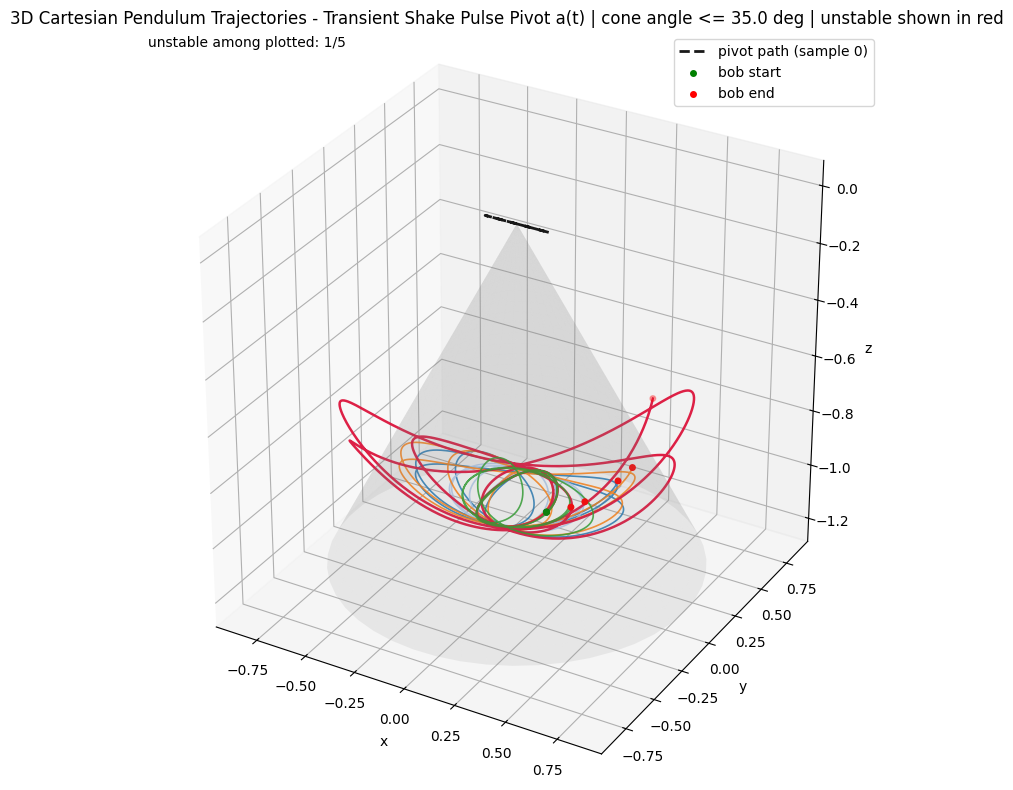

In [27]:
# End plot: same style for the transient shake-event family
N_pulse = 5
T_pulse = 10.0
dt_pulse = 0.005
t0_pulse = T_pulse / 2.0

X_pulse = sample_X_shake_pulse(
    N_pulse,
    A_range=(0.10, 0.2),
    omega_range=(1.0, 3),
    tau_range=(0.5, 2.5),
    t0=t0_pulse,
    q=np.array([1.0, 0.0, 0.0]),
    a0=np.array([0.0, 0.0, 0.0]),
    seed=23,
)

traj_pulse = simulate_cartesian_pendulum_custom(
    params=params,
    t_final=T_pulse,
    dt=dt_pulse,
    X=X_pulse,
    pivot_eval=pivot_shake_pulse_batch,
)
theta_max_deg=35
plot_many_3d_like_you_prefer(
    traj_pulse,
    "3D Cartesian Pendulum Trajectories - Transient Shake Pulse Pivot a(t)",
    theta_max_deg=theta_max_deg
)



In [54]:
# GIF animation for one transient-shake trajectory
from matplotlib.animation import FuncAnimation, PillowWriter

def save_single_traj_gif(traj, out_path=None, fps=30, stride=6, trail=160, theta_max_deg=25.0):
    if out_path is None:
        out_path = Path.cwd().resolve() / "figure" / "transient_shake_single_traj.gif"
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    t = traj["t"]
    r = traj["r"][0]  # single trajectory
    a = traj["a"][0]
    apex_fixed = a[0].copy()

    d = r - a
    ell_est = float(np.median(np.linalg.norm(d, axis=1)))

    frame_ids = np.arange(0, len(t), stride, dtype=int)
    if frame_ids[-1] != len(t) - 1:
        frame_ids = np.append(frame_ids, len(t) - 1)

    xyz_all = np.vstack([r, a])
    mins = xyz_all.min(axis=0)
    maxs = xyz_all.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = 0.6 * np.max(maxs - mins) + 0.25

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Transient Shake Pendulum (single trajectory)")

    pivot_line, = ax.plot([], [], [], "k--", lw=1.4, alpha=0.85, label="pivot path")
    bob_trail, = ax.plot([], [], [], color="tab:blue", lw=1.6, alpha=0.9, label="bob trail")
    rod_line, = ax.plot([], [], [], color="tab:orange", lw=2.2, label="rod")
    pivot_dot = ax.scatter([], [], [], color="black", s=30)
    bob_dot = ax.scatter([], [], [], color="tab:blue", s=36)

    # Cone wireframe artists (updated each frame around current pivot)
    n_rays = 12
    ray_lines = [ax.plot([], [], [], color="gray", lw=0.8, alpha=0.5)[0] for _ in range(n_rays)]
    cone_ring, = ax.plot([], [], [], color="gray", lw=1.0, alpha=0.8, label="safety cone")

    time_text = ax.text2D(0.02, 0.95, "", transform=ax.transAxes)
    status_text = ax.text2D(0.02, 0.90, "", transform=ax.transAxes)
    ax.legend(loc="upper right")

    theta = np.deg2rad(theta_max_deg)
    cone_h = 1.2 * ell_est
    cone_r = cone_h * np.tan(theta)
    ring_phi = np.linspace(0.0, 2.0 * np.pi, 200)

    def _set_scatter(sc, x, y, z):
        sc._offsets3d = ([x], [y], [z])

    def init():
        pivot_line.set_data([], [])
        pivot_line.set_3d_properties([])
        bob_trail.set_data([], [])
        bob_trail.set_3d_properties([])
        rod_line.set_data([], [])
        rod_line.set_3d_properties([])
        cone_ring.set_data([], [])
        cone_ring.set_3d_properties([])
        for rl in ray_lines:
            rl.set_data([], [])
            rl.set_3d_properties([])
        time_text.set_text("")
        status_text.set_text("")
        return (pivot_line, bob_trail, rod_line, pivot_dot, bob_dot, cone_ring, *ray_lines, time_text, status_text)

    def update(fi):
        j = frame_ids[fi]
        j0 = max(0, j - trail)

        pivot_line.set_data(a[: j + 1, 0], a[: j + 1, 1])
        pivot_line.set_3d_properties(a[: j + 1, 2])

        bob_trail.set_data(r[j0 : j + 1, 0], r[j0 : j + 1, 1])
        bob_trail.set_3d_properties(r[j0 : j + 1, 2])

        rod_line.set_data([a[j, 0], r[j, 0]], [a[j, 1], r[j, 1]])
        rod_line.set_3d_properties([a[j, 2], r[j, 2]])

        # Update moving cone anchored at pivot a[j]
        cx = apex_fixed[0] + cone_r * np.cos(ring_phi)
        cy = apex_fixed[1] + cone_r * np.sin(ring_phi)
        cz = np.full_like(cx, apex_fixed[2] - cone_h)
        cone_ring.set_data(cx, cy)
        cone_ring.set_3d_properties(cz)

        ray_phi = np.linspace(0.0, 2.0 * np.pi, n_rays, endpoint=False)
        for k, ph in enumerate(ray_phi):
            bx = apex_fixed[0] + cone_r * np.cos(ph)
            by = apex_fixed[1] + cone_r * np.sin(ph)
            bz = apex_fixed[2] - cone_h
            ray_lines[k].set_data([apex_fixed[0], bx], [apex_fixed[1], by])
            ray_lines[k].set_3d_properties([apex_fixed[2], bz])

        _set_scatter(pivot_dot, a[j, 0], a[j, 1], a[j, 2])
        _set_scatter(bob_dot, r[j, 0], r[j, 1], r[j, 2])

        u = (r[j] - a[j]) / max(np.linalg.norm(r[j] - a[j]), 1e-12)
        safe_now = (-u[2]) >= np.cos(theta)
        bob_dot._facecolor3d = ("tab:blue" if safe_now else "crimson")
        bob_dot._edgecolor3d = ("tab:blue" if safe_now else "crimson")

        time_text.set_text(f"t = {t[j]:.2f} s")
        status_text.set_text(f"status: {'SAFE' if safe_now else 'UNSAFE'}")
        status_text.set_color("tab:green" if safe_now else "crimson")
        return (pivot_line, bob_trail, rod_line, pivot_dot, bob_dot, cone_ring, *ray_lines, time_text, status_text)

    ani = FuncAnimation(fig, update, frames=len(frame_ids), init_func=init, interval=1000.0/fps, blit=False)
    ani.save(out_path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"Saved GIF: {out_path}")
    return out_path

gif_path = save_single_traj_gif(traj_pulse, fps=30, stride=6, trail=180, theta_max_deg=theta_max_deg)





Saved GIF: /home/mzheng/research/Physics-Informed-Hypo-Test/notebook/figure/transient_shake_single_traj.gif


In [90]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [105]:
# Multiple GIF variants with stronger safety/instability visibility
from matplotlib.animation import FuncAnimation, PillowWriter

def _cone_geom(apex, theta_rad, cone_h, n_ring=200):
    ring_phi = np.linspace(0.0, 2.0*np.pi, n_ring)
    cone_r = cone_h * np.tan(theta_rad)
    cx = apex[0] + cone_r*np.cos(ring_phi)
    cy = apex[1] + cone_r*np.sin(ring_phi)
    cz = np.full_like(cx, apex[2] - cone_h)
    return cx, cy, cz, cone_r


def _safe_mask_single(traj, theta_max_deg=25.0):
    r = traj['r'][0]
    a = traj['a'][0]
    apex_fixed = a[0].copy()
    d = r - a
    u = d / np.maximum(np.linalg.norm(d, axis=1, keepdims=True), 1e-12)
    m = -u[:, 2] - np.cos(np.deg2rad(theta_max_deg))
    safe = m >= 0.0
    return safe, m


def gif_variant_latch_banner(traj, out_path, theta_max_deg=25.0, fps=30, stride=6, trail=180, show_all_top_paths=True):
    t = traj['t']
    r_all = traj['r']
    a_all = traj['a']

    r = r_all[0]
    a = a_all[0]
    apex_fixed = a[0].copy()
    safe, m = _safe_mask_single({'t': t, 'r': r_all[:1], 'a': a_all[:1]}, theta_max_deg=theta_max_deg)

    d = r - a
    u = d / np.maximum(np.linalg.norm(d, axis=1, keepdims=True), 1e-12)
    theta_deg = np.degrees(np.arccos(np.clip(-u[:, 2], -1.0, 1.0)))

    frame_ids = list(np.arange(0, len(t), stride, dtype=int))
    if frame_ids[-1] != len(t)-1:
        frame_ids.append(len(t)-1)

    xyz_all = np.vstack([r, a])
    mins = xyz_all.min(axis=0); maxs = xyz_all.max(axis=0)
    center = 0.5*(mins+maxs); radius = 0.6*np.max(maxs-mins) + 0.25
    ell = float(np.median(np.linalg.norm(r-a, axis=1)))

    # 3-panel layout: 3D (left), theta diagnostic (middle), top view (right)
    fig = plt.figure(figsize=(16.2, 6.0))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.55, 1.0, 1.05])
    ax = fig.add_subplot(gs[0, 0], projection='3d')
    axd = fig.add_subplot(gs[0, 1])
    axt = fig.add_subplot(gs[0, 2])

    # Middle diagnostic subplot: theta(t) and threshold
    axd.plot(t, theta_deg, color='black', lw=1.9, label=r'$\varphi(t;X)$')
    axd.axhline(theta_max_deg, color='crimson', lw=2.0, linestyle='--', label=r'$\tau$')
    axd.fill_between(t, theta_deg, theta_max_deg, where=(theta_deg >= theta_max_deg), color='crimson', alpha=0.15)
    marker_theta, = axd.plot([], [], 'o', color='tab:blue', ms=7)
    vline = axd.axvline(0.0, color='tab:blue', lw=1.2, alpha=0.9)
    axd.set_title('Swing Angle vs Threshold', fontsize=12)
    axd.set_xlabel('time [s]')
    axd.set_ylabel(r'$\varphi$ [deg]')
    axd.grid(True, alpha=0.25)
    axd.legend(loc='upper right', fontsize=9)

    # Right top-view subplot: full trajectories + safety circle at a(0)
    cone_h = 1.2 * ell
    safe_radius_xy = cone_h * np.tan(np.deg2rad(theta_max_deg))
    pivot_x, pivot_y = apex_fixed[0], apex_fixed[1]

    axt.set_title('Top View (x-y): Trajectories vs Safety Radius', fontsize=12)
    axt.set_xlabel('x')
    axt.set_ylabel('y')
    axt.grid(True, alpha=0.25)
    axt.set_aspect('equal', adjustable='box')

    all_xy = np.vstack([r_all.reshape(-1, 3)[:, :2], a_all.reshape(-1, 3)[:, :2], np.array([[pivot_x + safe_radius_xy, pivot_y], [pivot_x - safe_radius_xy, pivot_y], [pivot_x, pivot_y + safe_radius_xy], [pivot_x, pivot_y - safe_radius_xy]])])
    min_xy = all_xy.min(axis=0)
    max_xy = all_xy.max(axis=0)
    pad_xy = 0.08 * np.max(max_xy - min_xy) + 0.05
    axt.set_xlim(min_xy[0] - pad_xy, max_xy[0] + pad_xy)
    axt.set_ylim(min_xy[1] - pad_xy, max_xy[1] + pad_xy)

    circle = plt.Circle((pivot_x, pivot_y), safe_radius_xy, edgecolor='black', facecolor='none', linestyle='--', linewidth=1.8, alpha=0.9)
    axt.add_patch(circle)
    axt.scatter([pivot_x], [pivot_y], c='k', s=30, label=r'u(0;X)')

    # static background: all trajectories (if available)
    if show_all_top_paths and r_all.shape[0] > 1:
        for i in range(r_all.shape[0]):
            axt.plot(r_all[i, :, 0], r_all[i, :, 1], color='0.82', lw=0.8, alpha=0.6)

    # highlighted trajectory (sample 0)
    axt.plot(r[:, 0], r[:, 1], color='tab:blue', lw=1.2, alpha=0.45, label='sample 0 full path')
    top_trail_safe, = axt.plot([], [], color='tab:blue', lw=2.0, label='sample 0 live trail')
    top_trail_bad, = axt.plot([], [], color='crimson', lw=2.4)
    top_dot, = axt.plot([], [], 'o', color='tab:blue', ms=7)
    axt.legend(loc='upper right', fontsize=8)

    # Left 3D panel
    ax.set_xlim(center[0]-radius, center[0]+radius)
    ax.set_ylim(center[1]-radius, center[1]+radius)
    ax.set_zlim(center[2]-radius, center[2]+radius)
    ax.set_box_aspect((1,1,1))
    ax.set_title('Variant A: Cone Boundary Contact is Highlighted', fontsize=12)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

    # add a light, fixed cone surface for clearer geometry
    cone_phi = np.linspace(0.0, 2.0*np.pi, 40)
    cone_h_samples = np.linspace(0.0, cone_h, 18)
    P, H = np.meshgrid(cone_phi, cone_h_samples)
    Rm = H * np.tan(np.deg2rad(theta_max_deg))
    Xs = apex_fixed[0] + Rm * np.cos(P)
    Ys = apex_fixed[1] + Rm * np.sin(P)
    Zs = apex_fixed[2] - H
    ax.plot_surface(Xs, Ys, Zs, color='gray', alpha=0.08, linewidth=0, shade=False)

    pivot_line, = ax.plot([], [], [], 'k--', lw=1.2, alpha=0.85, label='pivot path')
    bob_trail, = ax.plot([], [], [], color='tab:blue', lw=1.8, alpha=0.9, label='bob trail')
    rod_line, = ax.plot([], [], [], color='tab:orange', lw=2.4, label='rod')
    pivot_dot = ax.scatter([], [], [], c='k', s=26)
    bob_dot = ax.scatter([], [], [], c='tab:blue', s=48, edgecolors='none')
    bob_glow = ax.scatter([], [], [], c='none', s=230, edgecolors='none')

    cone_ring, = ax.plot([], [], [], color='gray', lw=1.0, alpha=0.85, label='safety cone')
    n_rays = 12
    ray_lines = [ax.plot([], [], [], color='gray', lw=0.8, alpha=0.5)[0] for _ in range(n_rays)]

    txt_time = ax.text2D(0.02, 0.95, '', transform=ax.transAxes)
    txt_now = ax.text2D(0.02, 0.90, '', transform=ax.transAxes)
    ax.legend(loc='upper right', fontsize=9)

    theta = np.deg2rad(theta_max_deg)

    def _set_scatter(sc, x, y, z):
        sc._offsets3d = ([x], [y], [z])

    def update(k):
        j = frame_ids[k]
        j0 = max(0, j-trail)

        # 3D updates
        pivot_line.set_data(a[:j+1,0], a[:j+1,1]); pivot_line.set_3d_properties(a[:j+1,2])
        bob_trail.set_data(r[j0:j+1,0], r[j0:j+1,1]); bob_trail.set_3d_properties(r[j0:j+1,2])
        rod_line.set_data([a[j,0], r[j,0]], [a[j,1], r[j,1]])
        rod_line.set_3d_properties([a[j,2], r[j,2]])

        cx, cy, cz, cone_r = _cone_geom(apex_fixed, theta, cone_h)
        cone_ring.set_data(cx, cy); cone_ring.set_3d_properties(cz)
        rays = np.linspace(0, 2*np.pi, n_rays, endpoint=False)
        for ii, ph in enumerate(rays):
            bx = apex_fixed[0] + cone_r*np.cos(ph); by = apex_fixed[1] + cone_r*np.sin(ph); bz = apex_fixed[2]-cone_h
            ray_lines[ii].set_data([apex_fixed[0], bx], [apex_fixed[1], by]); ray_lines[ii].set_3d_properties([apex_fixed[2], bz])

        _set_scatter(pivot_dot, a[j,0], a[j,1], a[j,2])
        _set_scatter(bob_dot, r[j,0], r[j,1], r[j,2])
        _set_scatter(bob_glow, r[j,0], r[j,1], r[j,2])

        # Top view updates (sample 0 live trail)
        idx = np.arange(j0, j+1)
        top_rad = np.sqrt((r[idx,0] - pivot_x)**2 + (r[idx,1] - pivot_y)**2)
        safe_idx = idx[top_rad <= safe_radius_xy]
        bad_idx = idx[top_rad > safe_radius_xy]
        if len(safe_idx) > 0:
            top_trail_safe.set_data(r[safe_idx,0], r[safe_idx,1])
        else:
            top_trail_safe.set_data([], [])
        if len(bad_idx) > 0:
            top_trail_bad.set_data(r[bad_idx,0], r[bad_idx,1])
        else:
            top_trail_bad.set_data([], [])
        top_dot.set_data([r[j,0]], [r[j,1]])
        top_now_bad = np.sqrt((r[j,0]-pivot_x)**2 + (r[j,1]-pivot_y)**2) > safe_radius_xy

        # Contact or exceed boundary => red emphasis
        is_contact_or_exceed = (m[j] <= 0.0)
        if not is_contact_or_exceed:
            bob_dot._facecolor3d = ('tab:blue',); bob_dot._edgecolor3d = ('tab:blue',)
            bob_glow._facecolor3d = ((0,0,0,0),); bob_glow._edgecolor3d = ((0,0,0,0),)
            rod_line.set_color('tab:orange'); rod_line.set_linewidth(2.4)
            txt_now.set_text('current: SAFE'); txt_now.set_color('tab:green')
            marker_theta.set_color('tab:blue'); vline.set_color('tab:blue')
            top_dot.set_color('crimson' if top_now_bad else 'tab:blue')
        else:
            bob_dot._facecolor3d = ('crimson',); bob_dot._edgecolor3d = ('black',)
            bob_glow._facecolor3d = ((1,0,0,0.12),); bob_glow._edgecolor3d = ((1,0,0,0.35),)
            rod_line.set_color('crimson'); rod_line.set_linewidth(3.4)
            txt_now.set_text('current: CONTACT/UNSAFE'); txt_now.set_color('crimson')
            marker_theta.set_color('crimson'); vline.set_color('crimson')
            top_dot.set_color('crimson' if top_now_bad else 'tab:blue')

        txt_time.set_text(f't = {t[j]:.2f}s | theta={theta_deg[j]:.2f} deg')

        marker_theta.set_data([t[j]], [theta_deg[j]])
        vline.set_xdata([t[j], t[j]])

        return pivot_line, bob_trail, rod_line, pivot_dot, bob_dot, bob_glow, cone_ring, *ray_lines, txt_time, txt_now, marker_theta, vline, top_trail_safe, top_trail_bad, top_dot

    ani = FuncAnimation(fig, update, frames=len(frame_ids), interval=1000/fps, blit=False)
    out_path = Path(out_path); out_path.parent.mkdir(parents=True, exist_ok=True)
    ani.save(out_path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print('Saved', out_path)


def save_variantA_static_overview(traj, out_path, theta_max_deg=25.0, show_all_top_paths=True):
    title_fs = 13
    legend_fs = 11
    axis_label_fs = 11
    tick_fs = 10

    title_y = 1.1

    t = traj['t']
    r_all = traj['r']
    a_all = traj['a']

    r = r_all[0]
    a = a_all[0]
    apex_fixed = a[0].copy()

    d = r - a
    u = d / np.maximum(np.linalg.norm(d, axis=1, keepdims=True), 1e-12)
    theta_deg = np.degrees(np.arccos(np.clip(-u[:, 2], -1.0, 1.0)))
    m = -u[:, 2] - np.cos(np.deg2rad(theta_max_deg))
    safe = m >= 0.0

    xyz_all = np.vstack([r, a])
    mins = xyz_all.min(axis=0); maxs = xyz_all.max(axis=0)
    center = 0.5*(mins+maxs); radius = 0.6*np.max(maxs-mins) + 0.25
    ell = float(np.median(np.linalg.norm(r-a, axis=1)))
    cone_h = 1.2 * ell
    safe_radius_xy = cone_h * np.tan(np.deg2rad(theta_max_deg))

    fig = plt.figure(figsize=(18.8, 6.2), constrained_layout=False)
    gs = fig.add_gridspec(
        1, 3,
        width_ratios=[1, 1, 1],   # same subfigure size
        left=0.04, right=0.99,
        bottom=0.10, top=0.92,
        wspace=0.22               # same gap between panels
    )


    ax = fig.add_subplot(gs[0, 0], projection='3d')
    axt = fig.add_subplot(gs[0, 1])
    axd = fig.add_subplot(gs[0, 2])

    ax.set_anchor('C')
    axt.set_anchor('C')
    axd.set_anchor('C')

    # 3D trajectory segments (safe/unsafe split without cross-jump artifacts)
    bad = ~safe

    def _plot_contiguous_by_mask_3d(ax3d, rr, mask, color, lw, alpha, label=None):
        idx = np.flatnonzero(mask)
        if idx.size == 0:
            return False
        breaks = np.where(np.diff(idx) > 1)[0] + 1
        runs = np.split(idx, breaks)
        first = True
        for run in runs:
            ax3d.plot(
                rr[run, 0], rr[run, 1], rr[run, 2],
                color=color, lw=lw, alpha=alpha,
                label=(label if first else None),
            )
            first = False
        return True

    _plot_contiguous_by_mask_3d(ax, r, safe, color='tab:blue', lw=1.8, alpha=0.9, label='stable trajectory segment')
    _plot_contiguous_by_mask_3d(ax, r, bad, color='crimson', lw=2.4, alpha=0.95, label='unstable trajectory segment')
    ax.plot(a[:, 0], a[:, 1], a[:, 2], 'k--', lw=1.2, alpha=0.85, label='pivot trajectory')
    legend_handles = [
        Line2D([0], [0], color='tab:blue', lw=2, label='stable trajectory segment'),
        Line2D([0], [0], color='crimson', lw=2, label='unstable trajectory segment'),
        Line2D([0], [0], color='k', lw=1.2, linestyle='--', label='pivot trajectory'),
        Patch(facecolor='gray', edgecolor='gray', alpha=0.4, label='stability boundary cone'),  # <- shadow style
    ]

    # ax.legend(handles=legend_handles, loc='upper right', fontsize=legend_fs, framealpha=0.95)

    cone_phi = np.linspace(0.0, 2.0*np.pi, 40)
    cone_h_samples = np.linspace(0.0, cone_h, 18)
    P, H = np.meshgrid(cone_phi, cone_h_samples)
    Rm = H * np.tan(np.deg2rad(theta_max_deg))
    Xs = apex_fixed[0] + Rm * np.cos(P)
    Ys = apex_fixed[1] + Rm * np.sin(P)
    Zs = apex_fixed[2] - H
    ax.plot_surface(Xs, Ys, Zs, color='gray', alpha=0.2, linewidth=0, shade=False)
    # explicit legend handle for cone constraint
    # ax.plot([], [], [], linestyle='--', color='gray', lw=1.5, label='cone constraint')

    ax.set_xlim(center[0]-radius, center[0]+radius)
    ax.set_ylim(center[1]-radius, center[1]+radius)
    ax.set_zlim(center[2]-radius, center[2]+radius)
    ax.set_box_aspect((1,1,1))
    ax.set_title('3D View: Trajectory with cone shape stability boundary', fontsize=title_fs,y=title_y+0.045)
    ax.set_xlabel('x',fontsize=axis_label_fs); ax.set_ylabel('y',fontsize=axis_label_fs); ax.set_zlabel('z',fontsize=axis_label_fs)
    ax.legend(handles=legend_handles, loc='upper left', fontsize=legend_fs)

    # middle: 2D projection with all trajectories
    pivot_x, pivot_y = apex_fixed[0], apex_fixed[1]
    circle = plt.Circle((pivot_x, pivot_y), safe_radius_xy, edgecolor='black', facecolor='none', linestyle='--', linewidth=1.8, alpha=0.9)
    axt.add_patch(circle)
    axt.scatter([pivot_x], [pivot_y], c='k', s=30, label=r'u(0;X)')

    def _plot_contiguous_by_mask(ax2d, rr, mask, color, lw, alpha, label=None):
        idx = np.flatnonzero(mask)
        if idx.size == 0:
            return False
        breaks = np.where(np.diff(idx) > 1)[0] + 1
        runs = np.split(idx, breaks)
        first = True
        for run in runs:
            ax2d.plot(
                rr[run, 0], rr[run, 1],
                color=color, lw=lw, alpha=alpha,
                label=(label if first else None),
            )
            first = False
        return True

    first_inside = True
    first_outside = True
    if show_all_top_paths:
        for i in range(r_all.shape[0]):
            rr = r_all[i]
            top_bad_i = np.sqrt((rr[:, 0] - pivot_x)**2 + (rr[:, 1] - pivot_y)**2) > safe_radius_xy
            top_good_i = ~top_bad_i

            drew_in = _plot_contiguous_by_mask(
                axt, rr, top_good_i,
                color='tab:blue', lw=1.2, alpha=0.8,
                label='stable trajectory segment' if first_inside else None,
            )
            if drew_in:
                first_inside = False

            drew_out = _plot_contiguous_by_mask(
                axt, rr, top_bad_i,
                color='crimson', lw=1.8, alpha=0.9,
                label='unstable trajectory segment' if first_outside else None,
            )
            if drew_out:
                first_outside = False
    else:
        # fallback: only sample 0
        top_bad = np.sqrt((r[:,0] - pivot_x)**2 + (r[:,1] - pivot_y)**2) > safe_radius_xy
        top_good = ~top_bad
        _plot_contiguous_by_mask(axt, r, top_good, color='tab:blue', lw=1.4, alpha=0.9, label='stable trajectory segment')
        _plot_contiguous_by_mask(axt, r, top_bad, color='crimson', lw=2.2, alpha=0.9, label='unstable trajectory segment')

    all_xy = np.vstack([
        r_all.reshape(-1, 3)[:, :2],
        a_all.reshape(-1, 3)[:, :2],
        np.array([
            [pivot_x + safe_radius_xy, pivot_y],
            [pivot_x - safe_radius_xy, pivot_y],
            [pivot_x, pivot_y + safe_radius_xy],
            [pivot_x, pivot_y - safe_radius_xy],
        ])
    ])
    min_xy = all_xy.min(axis=0)
    max_xy = all_xy.max(axis=0)
    pad_xy = 0.08 * np.max(max_xy - min_xy) + 0.05
    axt.set_xlim(min_xy[0] - pad_xy, max_xy[0] + pad_xy)
    axt.set_ylim(min_xy[1] - pad_xy, max_xy[1] + pad_xy)
    axt.set_aspect('equal', adjustable='box')
    axt.set_title('Equivalent 2D Projection of Trajectory with circle shape stability boundary', fontsize=title_fs, y=title_y)
    axt.set_xlabel('x', fontsize=axis_label_fs)
    axt.set_ylabel('y', fontsize=axis_label_fs)
    axt.grid(True, alpha=0.25)
    legend_handles_2d = [
        Line2D([0], [0], marker='o', color='k', linestyle='None', markersize=6, label=r'u(0;X)'),
        Line2D([0], [0], color='tab:blue', lw=2, label='stable trajectory segment'),
        Line2D([0], [0], color='crimson', lw=2, label='unstable trajectory segment'),
        Line2D([0], [0], color='black', lw=1.8, linestyle='--', label='stability boundary circle'),  # dashed circle proxy
    ]

    axt.legend(handles=legend_handles_2d, loc='upper left', fontsize=legend_fs, framealpha=0.95)

    # axt.legend(loc='upper left', fontsize=legend_fs)

    # right: single-angle diagnostic
    axd.plot(t, theta_deg, color='black', lw=1.9, label=r'$\varphi(t;X)$')
    axd.axhline(theta_max_deg, color='crimson', lw=2.0, linestyle='--', label=r'$\tau$')
    axd.fill_between(t, theta_deg, theta_max_deg, where=(theta_deg >= theta_max_deg), color='crimson', alpha=0.15)
    axd.set_title(r'Swing Angle $\varphi(t;X)$ vs Threshold $\tau$', fontsize=title_fs, y=title_y-0.055)
    axd.set_xlabel('time', fontsize=axis_label_fs)
    axd.set_ylabel(r'$\varphi(t;X)$', fontsize=axis_label_fs)
    axd.grid(True, alpha=0.25)
    axd.legend(loc='upper left', fontsize=legend_fs)

    out_path = Path(out_path); out_path.parent.mkdir(parents=True, exist_ok=True)
    # fig.tight_layout()
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print('Saved', out_path)


# Generate GIFs (Variant A active)
gif_dir = Path.cwd().resolve() / 'figure'
# gif_variant_latch_banner(
#     traj_pulse,
#     out_path=gif_dir / 'transient_shake_variantA_simple_theta_right.gif',
#     theta_max_deg=theta_max_deg,
#     fps=30,
#     stride=6,
#     trail=180,
# )
save_variantA_static_overview(
    traj_pulse,
    out_path=gif_dir / 'Cartesian_Pendulu_Demo.png',
    theta_max_deg=theta_max_deg,
    show_all_top_paths=True,
)
print('GIF/PNG saved in', gif_dir)

# gif_variant_colored_trail_pause(
#     traj_pulse,
#     out_path=gif_dir / 'transient_shake_variantB_colored_trail_pause.gif',
#     theta_max_deg=25.0,
#     fps=30,
#     stride=6,
#     trail=220,
#     pause_frames=25,
# )
# gif_variant_with_margin_subplot(
#     traj_pulse,
#     out_path=gif_dir / 'transient_shake_variantC_margin_subplot.gif',
#     theta_max_deg=25.0,
#     fps=30,
#     stride=6,
#     trail=180,
# )














Saved /home/mzheng/research/Physics-Informed-Hypo-Test/notebook/figure/Cartesian_Pendulu_Demo.png
GIF/PNG saved in /home/mzheng/research/Physics-Informed-Hypo-Test/notebook/figure


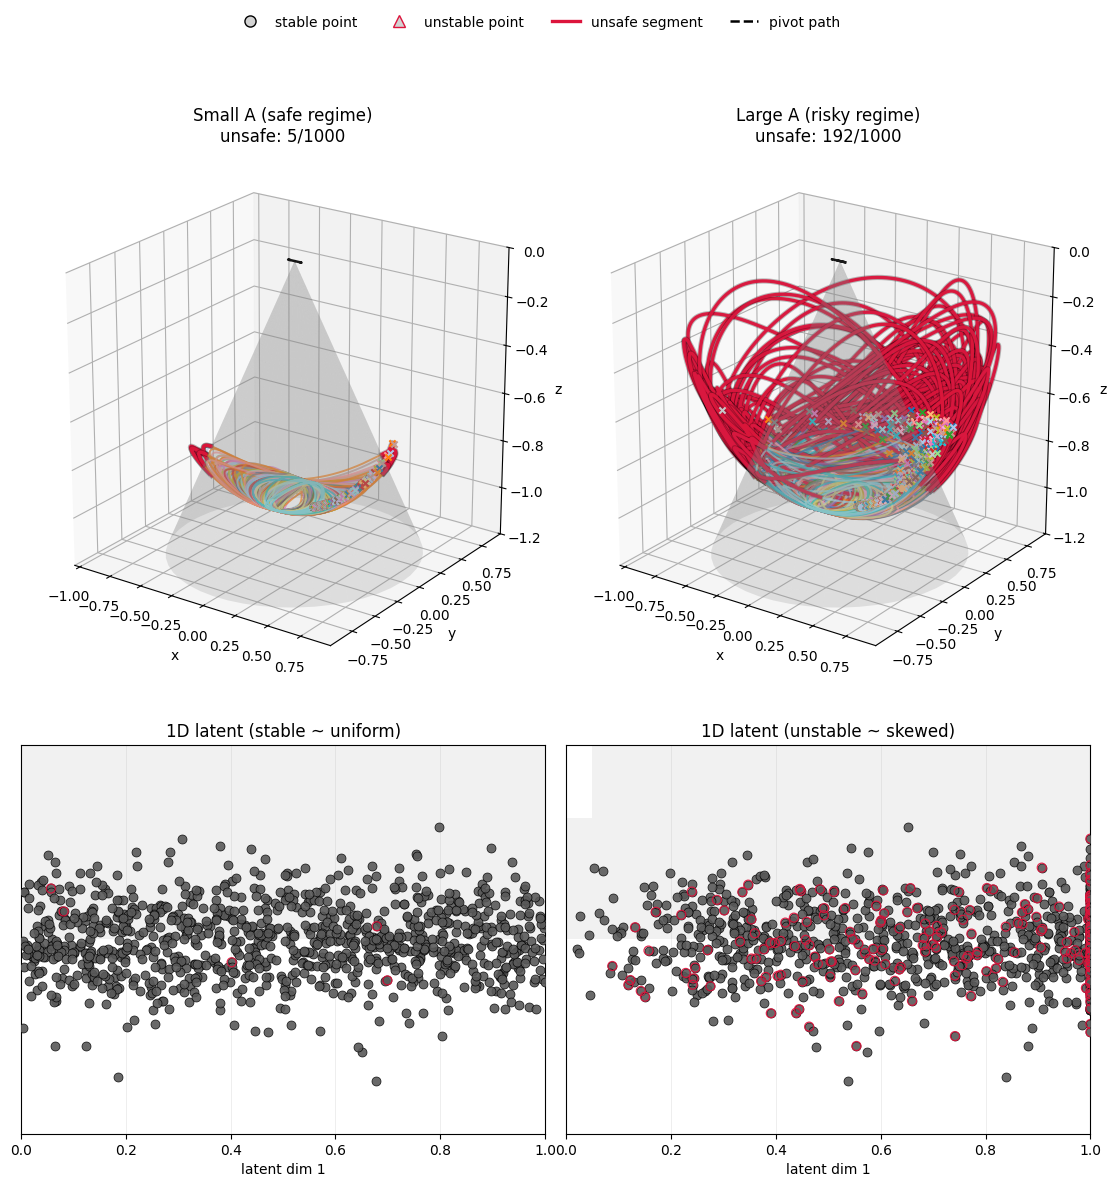

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch

# ---------- helpers ----------
def _safety_masks(traj, theta_max_deg):
    r, a = traj["r"], traj["a"]
    d = r - a
    u = d / np.maximum(np.linalg.norm(d, axis=2, keepdims=True), 1e-12)
    cos_th = np.clip(-u[:, :, 2], -1.0, 1.0)
    theta_deg = np.degrees(np.arccos(cos_th))
    safe_mask = theta_deg <= theta_max_deg
    is_stable = np.all(safe_mask, axis=1)
    return safe_mask, is_stable, theta_deg

def _minmax(x):
    x = np.asarray(x, float)
    if x.size == 0:
        return x
    lo, hi = x.min(), x.max()
    if hi - lo < 1e-12:
        return np.full_like(x, 0.5)
    return (x - lo) / (hi - lo)

def _cone_bbox_points(apex, theta_max_deg, cone_height):
    apex = np.asarray(apex, dtype=float)
    th = np.deg2rad(theta_max_deg)
    r = cone_height * np.tan(th)
    zb = apex[2] - cone_height
    ang = np.linspace(0, 2 * np.pi, 16, endpoint=False)
    base = np.column_stack([
        apex[0] + r * np.cos(ang),
        apex[1] + r * np.sin(ang),
        np.full_like(ang, zb),
    ])
    return np.vstack([apex[None, :], base])

def _auto_limits_from_points(pts, axis_mode="auto_rect", axis_scale=(1, 1, 1), axis_pad=(0.02, 0.02, 0.02)):
    mn, mx = pts.min(axis=0), pts.max(axis=0)
    c = 0.5 * (mn + mx)
    span = (mx - mn).astype(float)
    if axis_mode == "auto_cube":
        span[:] = span.max()
    span *= np.asarray(axis_scale, float)
    half = 0.5 * span * (1.0 + np.asarray(axis_pad, float))
    return (c[0] - half[0], c[0] + half[0]), \
           (c[1] - half[1], c[1] + half[1]), \
           (c[2] - half[2], c[2] + half[2])

def _embed_to_2d(
    traj, ids, is_stable_ids, theta_deg, theta_max_deg, rng,
    stable_noise=0.0,      # e.g. 0.0
    unstable_noise=0.04,   # e.g. 0.03~0.08
):
    r, a = traj["r"], traj["a"]
    d = r[ids] - a[ids]
    ell = np.maximum(np.linalg.norm(d, axis=2), 1e-12)

    theta_max = theta_deg[ids].max(axis=1)
    rho_mean = (np.sqrt(d[:, :, 0]**2 + d[:, :, 1]**2) / ell).mean(axis=1)
    vio_ratio = (theta_deg[ids] > theta_max_deg).mean(axis=1)

    N = len(ids)
    pts = np.zeros((N, 2), float)

    st = is_stable_ids
    un = ~st

    # Stable: uniform base
    if st.any():
        pts[st, 0] = rng.uniform(0.0, 1.0, size=st.sum())
        pts[st, 1] = rng.uniform(0.0, 1.0, size=st.sum())

    # Unstable: skewed base
    if un.any():
        n = un.sum()
        s1 = _minmax(theta_max[un])
        s2 = _minmax(vio_ratio[un] + 0.25 * rho_mean[un])
        u = np.clip(0.65 * s1 + 0.35 * rng.beta(2.0, 8.0, size=n), 0.0, 1.0)
        v = np.clip(0.35 * s2 + 0.65 * rng.beta(6.0, 2.0, size=n), 0.0, 1.0)
        pts[un, 0], pts[un, 1] = u, v

    # Optional jitter
    if stable_noise > 0 and st.any():
        pts[st] += rng.uniform(0.0, stable_noise, size=(st.sum(), 2))
    if unstable_noise > 0 and un.any():
        pts[un] += rng.uniform(0.0, unstable_noise, size=(un.sum(), 2))

    pts = np.clip(pts, 0.0, 1.0)
    return pts

# ---------- main plot ----------
def plot_safe_risky_3d_with_2d(
    traj_safe, traj_risky,
    theta_max_deg=35.0,
    n_plot=20,
    cone_alpha=0.20,
    cone_color="gray",
    axis_mode="auto_rect",
    axis_scale=(1.0, 1.0, 1.0),
    axis_pad=(0.02, 0.02, 0.00),
    shared_limits=True,
    ax_zoom=1.0,
    seed=7,
):
    rng = np.random.default_rng(seed)
    Ns = min(n_plot, traj_safe["r"].shape[0], traj_risky["r"].shape[0])
    ids = np.arange(Ns)
    colors = plt.cm.tab20(np.arange(Ns) % 20)

    safe_mask_s, is_stable_s, theta_s = _safety_masks(traj_safe, theta_max_deg)
    safe_mask_r, is_stable_r, theta_r = _safety_masks(traj_risky, theta_max_deg)

    fig = plt.figure(figsize=(13.8, 13.0))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.45, 1.0], hspace=0.10, wspace=0.04)
    ax3d_s = fig.add_subplot(gs[0, 0], projection="3d")
    ax3d_r = fig.add_subplot(gs[0, 1], projection="3d")
    ax2d_s = fig.add_subplot(gs[1, 0])
    ax2d_r = fig.add_subplot(gs[1, 1])

    def draw3d(ax, traj, safe_mask, is_stable, title):
        r, a = traj["r"], traj["a"]
        d = r - a
        ell_est = float(np.median(np.linalg.norm(d, axis=2)))
        apex = a[0, 0]
        cone_h = 1.2 * ell_est

        _draw_reference_cone(
            ax, apex=apex, theta_max_deg=theta_max_deg,
            cone_height=cone_h, color=cone_color, alpha=cone_alpha
        )

        bad_count = 0
        for j, i in enumerate(ids):
            # identity color
            ax.plot(r[i, :, 0], r[i, :, 1], r[i, :, 2], color=colors[j], lw=1.4, alpha=0.70)

            # unsafe overlay
            bad = ~safe_mask[i]
            if bad.any():
                bad_count += 1
                x = np.ma.masked_where(~bad, r[i, :, 0])
                y = np.ma.masked_where(~bad, r[i, :, 1])
                z = np.ma.masked_where(~bad, r[i, :, 2])
                ax.plot(x, y, z, color="black", lw=3.8, alpha=0.25)
                ax.plot(x, y, z, color="crimson", lw=2.4, alpha=0.95)

            ax.scatter(r[i, 0, 0], r[i, 0, 1], r[i, 0, 2], s=18, c=[colors[j]], marker="o")
            ax.scatter(r[i, -1, 0], r[i, -1, 1], r[i, -1, 2], s=20, c=[colors[j]], marker="x")

        ax.plot(a[0, :, 0], a[0, :, 1], a[0, :, 2], "k--", lw=1.8, alpha=0.9)
        ax.set_title(f"{title}\nunsafe: {bad_count}/{Ns}", pad=8)
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
        ax.view_init(elev=22, azim=-55)
        ax.set_box_aspect((1, 1, 1), zoom=ax_zoom)

        pts = np.concatenate([
            r[ids].reshape(-1, 3),
            a[:1].reshape(-1, 3),
            _cone_bbox_points(apex, theta_max_deg, cone_h),
        ], axis=0)
        return pts

    pts3d_s = draw3d(ax3d_s, traj_safe, safe_mask_s, is_stable_s, "Small A (safe regime)")
    pts3d_r = draw3d(ax3d_r, traj_risky, safe_mask_r, is_stable_r, "Large A (risky regime)")

    if shared_limits:
        ax_x, ax_y, ax_z = _auto_limits_from_points(
            np.concatenate([pts3d_s, pts3d_r], axis=0),
            axis_mode=axis_mode, axis_scale=axis_scale, axis_pad=axis_pad
        )
        for ax in (ax3d_s, ax3d_r):
            ax.set_xlim(*ax_x); ax.set_ylim(*ax_y); ax.set_zlim(*ax_z)

    # 2D embeddings per panel
    emb_s = _embed_to_2d(traj_safe, ids, is_stable_s[ids], theta_s, theta_max_deg, rng)
    emb_r = _embed_to_2d(traj_risky, ids, is_stable_r[ids], theta_r, theta_max_deg, rng, stable_noise=0.3, unstable_noise=1)

    # def draw2d(ax, emb, stable_mask, title):
    #     # subtle density backdrop
    #     if stable_mask.any():
    #         ax.hist2d(
    #             emb[stable_mask, 0], emb[stable_mask, 1],
    #             bins=12, range=[[0, 1], [0, 1]], cmap="Blues", alpha=0.22
    #         )
    #     if (~stable_mask).any():
    #         ax.hexbin(
    #             emb[~stable_mask, 0], emb[~stable_mask, 1],
    #             gridsize=14, extent=(0, 1, 0, 1), cmap="Reds", mincnt=1, alpha=0.22
    #         )

    #     # points keep trajectory identity color
    #     for j in range(len(emb)):
    #         stable_j = stable_mask[j]
    #         ax.scatter(
    #             emb[j, 0], emb[j, 1],
    #             s=72 if stable_j else 90,
    #             c=[colors[j]],
    #             marker="o" if stable_j else "^",
    #             edgecolors="black" if stable_j else "crimson",
    #             linewidths=0.9,
    #             alpha=0.95,
    #             zorder=3
    #         )

    #     ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    #     ax.set_aspect("equal", adjustable="box")
    #     ax.grid(alpha=0.25, lw=0.6)
    #     ax.set_xlabel("latent dim 1")
    #     ax.set_ylabel("latent dim 2")
    #     ax.set_title(title, pad=6)
    def draw2d(ax, emb, stable_mask, title):
        # subtle density backdrop (optional, keeps the structure visible)
        if stable_mask.any():
            ax.hist2d(
                emb[stable_mask, 0], emb[stable_mask, 1],
                bins=12, range=[[0, 1], [0, 1]], cmap="Greys", alpha=0.18
            )
        if (~stable_mask).any():
            ax.hexbin(
                emb[~stable_mask, 0], emb[~stable_mask, 1],
                gridsize=14, extent=(0, 1, 0, 1), cmap="Greys", mincnt=1, alpha=0.18
            )

        # one point style for all
        ax.scatter(
            emb[:, 0], emb[:, 1],
            s=55, marker="o",
            c="0.35", edgecolors="black", linewidths=0.6,
            alpha=0.9, zorder=3
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25, lw=0.6)
        ax.set_xlabel("latent dim 1")
        ax.set_ylabel("latent dim 2")
        ax.set_title(title, pad=6)


    # draw2d(ax2d_s, emb_s, is_stable_s[ids], "2D distribution (stable ~ uniform)")
    # draw2d(ax2d_r, emb_r, is_stable_r[ids], "2D distribution (unstable ~ skewed)")
    def draw1d(ax, emb, stable_mask, title, x_col=0):
        x = emb[:, x_col]
        y_jit = np.random.default_rng(0).normal(0.0, 0.03, size=len(x))  # vertical jitter only

        # Optional light density hint
        ax.hist(x, bins=20, range=(0, 1), density=True, color="0.85", alpha=0.35, edgecolor="none")

        # Same marker style for all points
        ax.scatter(
            x, y_jit,
            s=42, marker="o",
            c="0.35", edgecolors="black", linewidths=0.5,
            alpha=0.9, zorder=3
        )

        # Optional: mark unstable in a subtle overlay (same marker, different edge)
        un = ~stable_mask
        if un.any():
            ax.scatter(
                x[un], y_jit[un],
                s=42, marker="o",
                facecolors="none", edgecolors="crimson", linewidths=0.9,
                alpha=0.9, zorder=4
            )

        ax.set_xlim(0, 1)
        ax.set_ylim(-0.16, 0.16)
        ax.set_yticks([])
        ax.grid(axis="x", alpha=0.25, lw=0.6)
        ax.set_xlabel("latent dim 1")
        ax.set_title(title, pad=6)

    # usage
    draw1d(ax2d_s, emb_s, is_stable_s[ids], "1D latent (stable ~ uniform)", x_col=0)
    draw1d(ax2d_r, emb_r, is_stable_r[ids], "1D latent (unstable ~ skewed)", x_col=0)


    # Visual "pointing down" links from 3D row to 2D row
    # for a_top, a_bot in [(ax3d_s, ax2d_s), (ax3d_r, ax2d_r)]:
    #     con = ConnectionPatch(
    #         xyA=(0.5, -0.06), coordsA=a_top.transAxes,
    #         xyB=(0.5, 1.04),  coordsB=a_bot.transAxes,
    #         arrowstyle='-|>', lw=1.2, color='0.35', mutation_scale=14, alpha=0.8
    #     )
    #     fig.add_artist(con)

    # compact legend
    extra = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', markeredgecolor='k', label='stable point', markersize=8),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='lightgray', markeredgecolor='crimson', label='unstable point', markersize=8),
        Line2D([0], [0], color='crimson', lw=2.4, label='unsafe segment'),
        Line2D([0], [0], color='k', lw=1.8, ls='--', label='pivot path'),
    ]
    fig.legend(handles=extra, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.98))
    plt.show()

# Example:
num_traj = 1000
# X = sample_X_shake_pulse(A_distribution='gaussian')
traj_safe  = _simulate_pulse(A_range=(0.01, 0.08),omega_range=(1.0, 3.0),  tau_range=(0.5, 2.5),seed=23, N=num_traj)
traj_risky = _simulate_pulse(A_range=(0.01, 0.2),omega_range=(1.0, 5.0),  tau_range=(0.5, 2.5), seed=24, N=num_traj)
# plot_safe_vs_risky_3d(traj_safe, traj_risky,
#                       shared_limits=True,
#                       theta_max_deg=35,
#                       n_plot=,
#                       cone_alpha = 0.2,
#                       axis_mode="auto_rect",    
#                       axis_scale=(1.0, 1.0, 1),
#                       axis_pad=(0.02, 0.02, 0.00))   # per-axis padding fraction)


plot_safe_risky_3d_with_2d(
    traj_safe, traj_risky,
    shared_limits=True,
    theta_max_deg=35,
    n_plot=num_traj,
    cone_alpha=0.2,
    axis_mode="auto_rect",
    axis_scale=(1.0, 1.0, 1.0),
    axis_pad=(0.02, 0.02, 0.00),
)


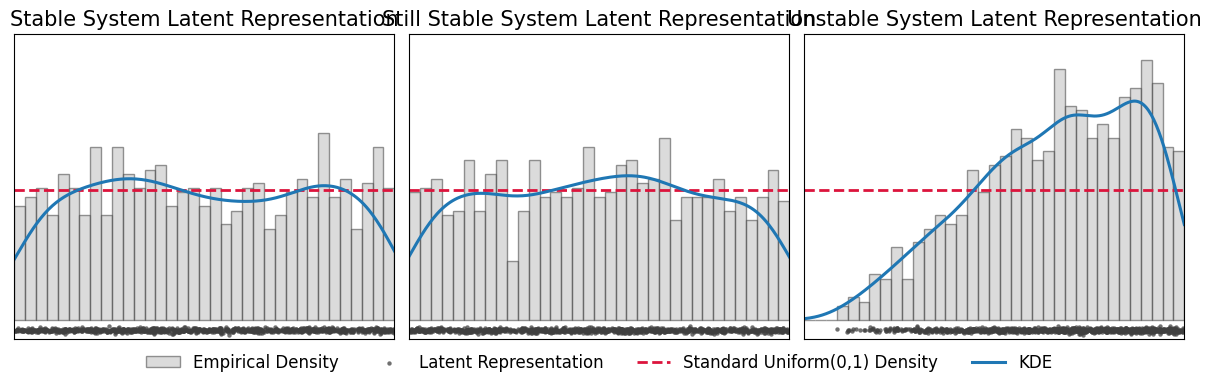

In [361]:
import numpy as np
import matplotlib.pyplot as plt


def plot_two_1d_uniform_comparison(
    n=1000,
    bins=35,
    seed=7,
    alpha_right=3.0,   # >1 puts more mass near x=1
    beta_right=1.2,
    use_kde=True,
):
    rng = np.random.default_rng(seed)

    # subplot 1: true uniform
    x_u = rng.uniform(0.0, 1.0, size=n)
    x_v = rng.uniform(0.0, 1.0, size=n)
    # subplot 2: weighted/"tilted uniform" (skewed toward one side)
    # Beta(alpha_right, beta_right) is a convenient weighted-uniform family
    x_w = rng.beta(alpha_right, beta_right, size=n)

    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

    def _draw(ax, x, title):
        # histogram density
        ax.hist(
            x, bins=bins, range=(0, 1), density=True,
            color="0.75", edgecolor="0.25", alpha=0.55, label="Empirical Density"
        )

        # jittered samples near bottom (for sample-level view)
        y_jit = -0.08 + rng.normal(0.0, 0.01, size=x.size)
        ax.scatter(
            x, y_jit, s=10, c="0.25", alpha=0.75, linewidths=0, label="Latent Representation"
        )

        # reference: standard uniform density f(x)=1
        ax.hlines(1.0, 0.0, 1.0, colors="crimson", linestyles="--", lw=2.0, label="Standard Uniform(0,1) Density")

        # optional KDE (simple Gaussian KDE implemented directly; no scipy needed)
        if use_kde:
            grid = np.linspace(0, 1, 300)
            # Silverman bandwidth
            s = np.std(x, ddof=1)
            h = max(1.06 * s * (len(x) ** (-1/5)), 1e-3)
            z = (grid[:, None] - x[None, :]) / h
            kde = np.mean(np.exp(-0.5 * z * z) / np.sqrt(2*np.pi), axis=1) / h
            ax.plot(grid, kde, color="#1f77b4", lw=2.2, label="KDE")

        ax.set_xlim(0, 1)
        ax.set_ylim(-0.15, max(2.2, ax.get_ylim()[1]))
        ax.set_xticks([])
        ax.set_yticks([])
        # ax.set_xlabel("x")
        ax.set_title(title,fontsize=15)
        # ax.grid(alpha=0.25, lw=0.6)

    _draw(axs[0], x_u, "Stable System Latent Representation")
    _draw(axs[1], x_v, "Still Stable System Latent Representation")
    _draw(axs[2], x_w, f"Unstable System Latent Representation")

    # axs[0].set_ylabel("Density")
    # axs[0].set_xlabel("")
    # axs[0].set_xlabel("Latent Representation")
    # axs[1].set_xlabel("Latent Representation")
    handles, labels = axs[1].get_legend_handles_labels()
    fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),  # decrease y to move down more
    ncol=4,
    frameon=False,
    fontsize = 12
)
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()
    return x_u, x_v, x_w



x_u, x_v, x_w = plot_two_1d_uniform_comparison(n=1000, alpha_right=2.5, beta_right=1.3, use_kde=True,seed=1)


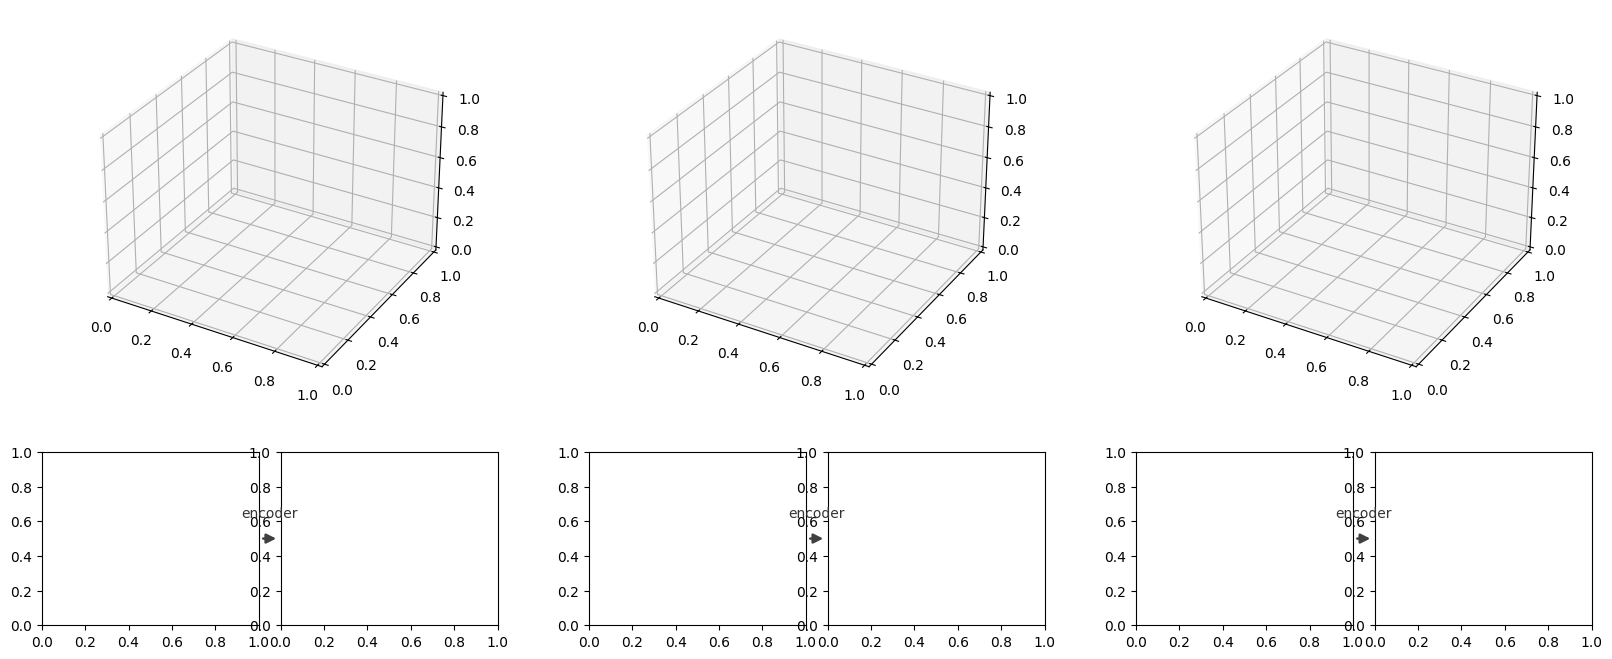

In [ ]:
fig = plt.figure(figsize=(21, 8))
outer = fig.add_gridspec(2, 3, height_ratios=[2.2, 1.0], wspace=0.20, hspace=0.22)

axs3d = [fig.add_subplot(outer[0, j], projection="3d") for j in range(3)]

ctx_axes, lat_axes = [], []
for j in range(3):
    sub = outer[1, j].subgridspec(1, 2, wspace=0.10)
    ctx_axes.append(fig.add_subplot(sub[0, 0]))
    lat_axes.append(fig.add_subplot(sub[0, 1]))
from matplotlib.patches import ConnectionPatch

for j in range(3):
    con = ConnectionPatch(
        xyA=(1.02, 0.5), coordsA=ctx_axes[j].transAxes,
        xyB=(-0.02, 0.5), coordsB=lat_axes[j].transAxes,
        arrowstyle='-|>', lw=1.8, color='0.25', mutation_scale=14
    )
    fig.add_artist(con)

    # label
    p1 = fig.transFigure.inverted().transform(ctx_axes[j].transAxes.transform((1.02, 0.56)))
    p2 = fig.transFigure.inverted().transform(lat_axes[j].transAxes.transform((-0.02, 0.56)))
    fig.text((p1[0]+p2[0])/2, (p1[1]+p2[1])/2 + 0.01, "encoder",
             ha="center", va="bottom", fontsize=10, color="0.2")


In [379]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

try:
    import seaborn as sns
    _HAS_SNS = True
except Exception:
    _HAS_SNS = False


def set_conference_style():
    if _HAS_SNS:
        sns.set_theme(style="white", context="paper", font_scale=1.15)
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "axes.titleweight": "semibold",
        "axes.labelcolor": "#2B2B2B",
        "axes.edgecolor": "#9AA0A6",
        "xtick.color": "#6E737A",
        "ytick.color": "#6E737A",
        "grid.color": "#DCE1E8",
        "grid.linewidth": 0.6,
        "font.family": "DejaVu Sans",
    })


def plot_three_column_nested(
    traj_base, traj_safe, traj_risky,
    A_base, w_base, A_safe, w_safe, A_risky, w_risky,
    z_base, z_safe, z_risky,
    titles=(r"Stable Baseline ($\mathbb{P}_0$)",
            r"Stable Shifted Context ($\mathbb{P}_1$)",
            r"Unstable Shifted Context ($\mathbb{P}_2$)"),
    theta_max_deg=30.0,
    n_plot=30,
    cone_alpha=0.10,
    fig_size=(18.5, 8.6),
    latent_xlim=(0.0, 1.0),
    latent_bins=24,
    latent_use_kde=True,
    latent_seed=7,
    hide_ticks=True,
    show_encoder_arrows=True,
    arrow_curvature=0.28,
):
    # ---- palette (conference-friendly) ----
    C = {
        "safe":   "#2E8B57",
        "unsafe": "#C0392B",
        "ctx0":   "#5A6C7D",
        "ctx1":   "#2F7D8A",
        "ctx2":   "#8A4F3D",
        "cone":   "#B8BEC5",
        "kde":    "#1F4E8C",
        "latent": "#3B3B3B",
        "axis3d": "#6F7680",
        "uniform":"#B13A3A",
    }

    def _safe_mask_from_d(d):
        u = d / np.maximum(np.linalg.norm(d, axis=2, keepdims=True), 1e-12)
        return (-u[:, :, 2]) >= np.cos(np.deg2rad(theta_max_deg))

    def _draw_cone(ax, h, theta_deg, alpha=0.10, color="#B8BEC5"):
        th = np.deg2rad(theta_deg)
        phi = np.linspace(0, 2*np.pi, 72)
        hh = np.linspace(0, h, 30)
        P, H = np.meshgrid(phi, hh)
        R = H * np.tan(th)
        X = R * np.cos(P)
        Y = R * np.sin(P)
        Z = -H
        ax.plot_surface(X, Y, Z, color=color, alpha=alpha, linewidth=0, shade=False)

    def _draw_back_axes(ax, color="#6F7680", lw=1.05):
        x0, x1 = ax.get_xlim3d()
        y0, y1 = ax.get_ylim3d()
        z0, z1 = ax.get_zlim3d()
        xb, yb, zb = x0, y1, z0
        ax.plot([x0, x1], [yb, yb], [zb, zb], color=color, lw=lw, zorder=0)
        ax.plot([xb, xb], [y0, y1], [zb, zb], color=color, lw=lw, zorder=0)
        ax.plot([xb, xb], [yb, yb], [z0, z1], color=color, lw=lw, zorder=0)

    def _kde_curve(x, lo=0.0, hi=1.0, n_grid=300):
        x = np.asarray(x, float)
        grid = np.linspace(lo, hi, n_grid)
        if len(x) < 2:
            return grid, np.zeros_like(grid)
        s = np.std(x, ddof=1)
        h = max(1.06 * s * (len(x) ** (-1/5)), 1e-3)
        z = (grid[:, None] - x[None, :]) / h
        kde = np.mean(np.exp(-0.5 * z * z) / np.sqrt(2*np.pi), axis=1) / h
        return grid, kde

    trajs = [traj_base, traj_safe, traj_risky]
    contexts = [(A_base, w_base), (A_safe, w_safe), (A_risky, w_risky)]
    latents = [np.asarray(z_base, float), np.asarray(z_safe, float), np.asarray(z_risky, float)]
    ctx_cols = [C["ctx0"], C["ctx1"], C["ctx2"]]

    Ns = min(n_plot, *(tr["r"].shape[0] for tr in trajs))
    ids = np.arange(Ns)

    fig = plt.figure(figsize=fig_size)
    outer = fig.add_gridspec(2, 3, height_ratios=[2.6, 1.0], wspace=0.12, hspace=0.06)

    ax3d = [fig.add_subplot(outer[0, j], projection="3d") for j in range(3)]
    ax_ctx, ax_lat = [], []
    for j in range(3):
        sub = outer[1, j].subgridspec(1, 2, width_ratios=[1.12, 1.0], wspace=0.09)
        ax_ctx.append(fig.add_subplot(sub[0, 0]))
        ax_lat.append(fig.add_subplot(sub[0, 1]))

    # ---------- top row ----------
    pts_all = []
    for j in range(3):
        d = trajs[j]["r"] - trajs[j]["a"]
        safe_mask = _safe_mask_from_d(d)
        ell = float(np.median(np.linalg.norm(d, axis=2)))
        cone_h = 1.2 * ell

        _draw_cone(ax3d[j], cone_h, theta_max_deg, alpha=cone_alpha, color=C["cone"])

        for i in ids:
            good = safe_mask[i]
            bad = ~good

            xg = np.ma.masked_where(~good, d[i, :, 0])
            yg = np.ma.masked_where(~good, d[i, :, 1])
            zg = np.ma.masked_where(~good, d[i, :, 2])
            ax3d[j].plot(xg, yg, zg, color=C["safe"], lw=1.8, alpha=0.80)

            xb = np.ma.masked_where(~bad, d[i, :, 0])
            yb = np.ma.masked_where(~bad, d[i, :, 1])
            zb = np.ma.masked_where(~bad, d[i, :, 2])
            ax3d[j].plot(xb, yb, zb, color="white", lw=3.6, alpha=0.65)   # halo
            ax3d[j].plot(xb, yb, zb, color=C["unsafe"], lw=2.0, alpha=0.95)

        ax3d[j].set_title(titles[j], fontsize=14, pad=8)
        ax3d[j].set_proj_type("ortho")
        ax3d[j].view_init(elev=22, azim=-55)
        ax3d[j].set_axis_off()

        pts_all.append(d[ids].reshape(-1, 3))
        rr = cone_h * np.tan(np.deg2rad(theta_max_deg))
        pts_all.append(np.array([[ rr, 0, -cone_h], [-rr, 0, -cone_h],
                                 [0, rr, -cone_h], [0, -rr, -cone_h], [0, 0, 0]]))

    P = np.concatenate(pts_all, axis=0)
    mn, mx = P.min(axis=0), P.max(axis=0)
    c = 0.5 * (mn + mx)
    half = 0.5 * np.max(mx - mn) * 1.03
    for ax in ax3d:
        ax.set_xlim(c[0]-half, c[0]+half)
        ax.set_ylim(c[1]-half, c[1]+half)
        ax.set_zlim(c[2]-half, c[2]+half)
        _draw_back_axes(ax, color=C["axis3d"], lw=1.1)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

    # ---------- shared limits for bottom ----------
    A_all = np.concatenate([A_base, A_safe, A_risky])
    w_all = np.concatenate([w_base, w_safe, w_risky])
    A_lim = (A_all.min(), A_all.max())
    w_lim = (w_all.min(), w_all.max())

    dens_max = 1.0
    if latent_use_kde:
        for z in latents:
            _, kde = _kde_curve(z, lo=latent_xlim[0], hi=latent_xlim[1])
            if kde.size:
                dens_max = max(dens_max, float(np.max(kde)))
    for z in latents:
        h, _ = np.histogram(z, bins=latent_bins, range=latent_xlim, density=True)
        if h.size:
            dens_max = max(dens_max, float(np.max(h)))
    latent_ymax = max(2.1, 1.10 * dens_max)

    rng = np.random.default_rng(latent_seed)

    # ---------- bottom row ----------
    for j in range(3):
        A, w = contexts[j]
        z = latents[j]

        # Context
        if _HAS_SNS:
            sns.kdeplot(x=A, y=w, ax=ax_ctx[j], fill=True, levels=8,
                        thresh=0.03, alpha=0.32, color=ctx_cols[j], linewidths=0)
            sns.kdeplot(x=A, y=w, ax=ax_ctx[j], levels=5,
                        color=ctx_cols[j], linewidths=1.0, alpha=0.95)
        ax_ctx[j].scatter(A, w, s=10, alpha=0.22, c=ctx_cols[j], edgecolors="none")
        ax_ctx[j].set_title("Context", fontsize=11, pad=2)
        ax_ctx[j].set_xlim(*A_lim); ax_ctx[j].set_ylim(*w_lim)
        ax_ctx[j].grid(alpha=0.22)

        # Latent
        ax_lat[j].hist(z, bins=latent_bins, range=latent_xlim, density=True,
                       color="#AEB5BD", edgecolor="white", linewidth=0.5, alpha=0.80)
        y_jit = -0.08 + rng.normal(0.0, 0.009, size=z.size)
        ax_lat[j].scatter(z, y_jit, s=9, c=C["latent"], alpha=0.72, linewidths=0)
        ax_lat[j].hlines(1.0, latent_xlim[0], latent_xlim[1],
                         colors=C["uniform"], linestyles=(0, (4, 3)), lw=1.8)

        if latent_use_kde:
            grid, kde = _kde_curve(z, lo=latent_xlim[0], hi=latent_xlim[1])
            ax_lat[j].plot(grid, kde, color=C["kde"], lw=2.0)

        ax_lat[j].set_title("Latent Representation", fontsize=11, pad=2)
        ax_lat[j].set_xlim(*latent_xlim)
        ax_lat[j].set_ylim(-0.15, latent_ymax)
        ax_lat[j].grid(alpha=0.18, axis="x")

        for ax in (ax_ctx[j], ax_lat[j]):
            ax.set_facecolor("#FBFCFE")
            for side in ax.spines:
                ax.spines[side].set_color("#C8CED8")
                ax.spines[side].set_linewidth(0.8)

        if hide_ticks:
            ax_ctx[j].set_xticks([]); ax_ctx[j].set_yticks([])
            ax_lat[j].set_xticks([]); ax_lat[j].set_yticks([])

    # optional encoder arrows
    if show_encoder_arrows:
        fig.canvas.draw()
        for j in range(3):
            b1 = ax_ctx[j].get_position()
            b2 = ax_lat[j].get_position()
            y_bot = min(b1.y0, b2.y0) - 0.016
            x1 = b1.x0 + 0.62 * b1.width
            x2 = b2.x0 + 0.38 * b2.width
            fig.add_artist(FancyArrowPatch(
                (x1, y_bot), (x2, y_bot),
                transform=fig.transFigure,
                connectionstyle=f"arc3,rad={arrow_curvature}",
                arrowstyle="->",
                mutation_scale=11,
                lw=1.2,
                color="#444",
                clip_on=False
            ))
            fig.text(0.5*(x1+x2), y_bot-0.008, "encoder",
                     ha="center", va="top", fontsize=9.5, color="#444")

    # single bottom legend
    handles = [
        Line2D([0], [0], color=C["safe"], lw=2, label="Stable segment"),
        Line2D([0], [0], color=C["unsafe"], lw=2, label="Unstable segment"),
        Line2D([0], [0], marker='o', linestyle='', markersize=6,
               markerfacecolor=ctx_cols[1], markeredgecolor="none", alpha=0.8, label="Context samples"),
        Line2D([0], [0], marker='o', linestyle='', markersize=5,
               markerfacecolor=C["latent"], markeredgecolor="none", alpha=0.9, label="Latent samples"),
        Line2D([0], [0], color=C["uniform"], linestyle=(0, (4, 3)), lw=2, label="Uniform(0,1) density"),
    ]
    if latent_use_kde:
        handles.append(Line2D([0], [0], color=C["kde"], lw=2.0, label="KDE"))

    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.012),
               ncol=len(handles), frameon=False, fontsize=10.5, handlelength=2.2, columnspacing=1.3)

    fig.subplots_adjust(left=0.03, right=0.995, top=0.93, bottom=0.14)
    plt.show()


/Users/mzheng/anaconda3/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/Users/mzheng/anaconda3/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/Users/mzheng/anaconda3/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


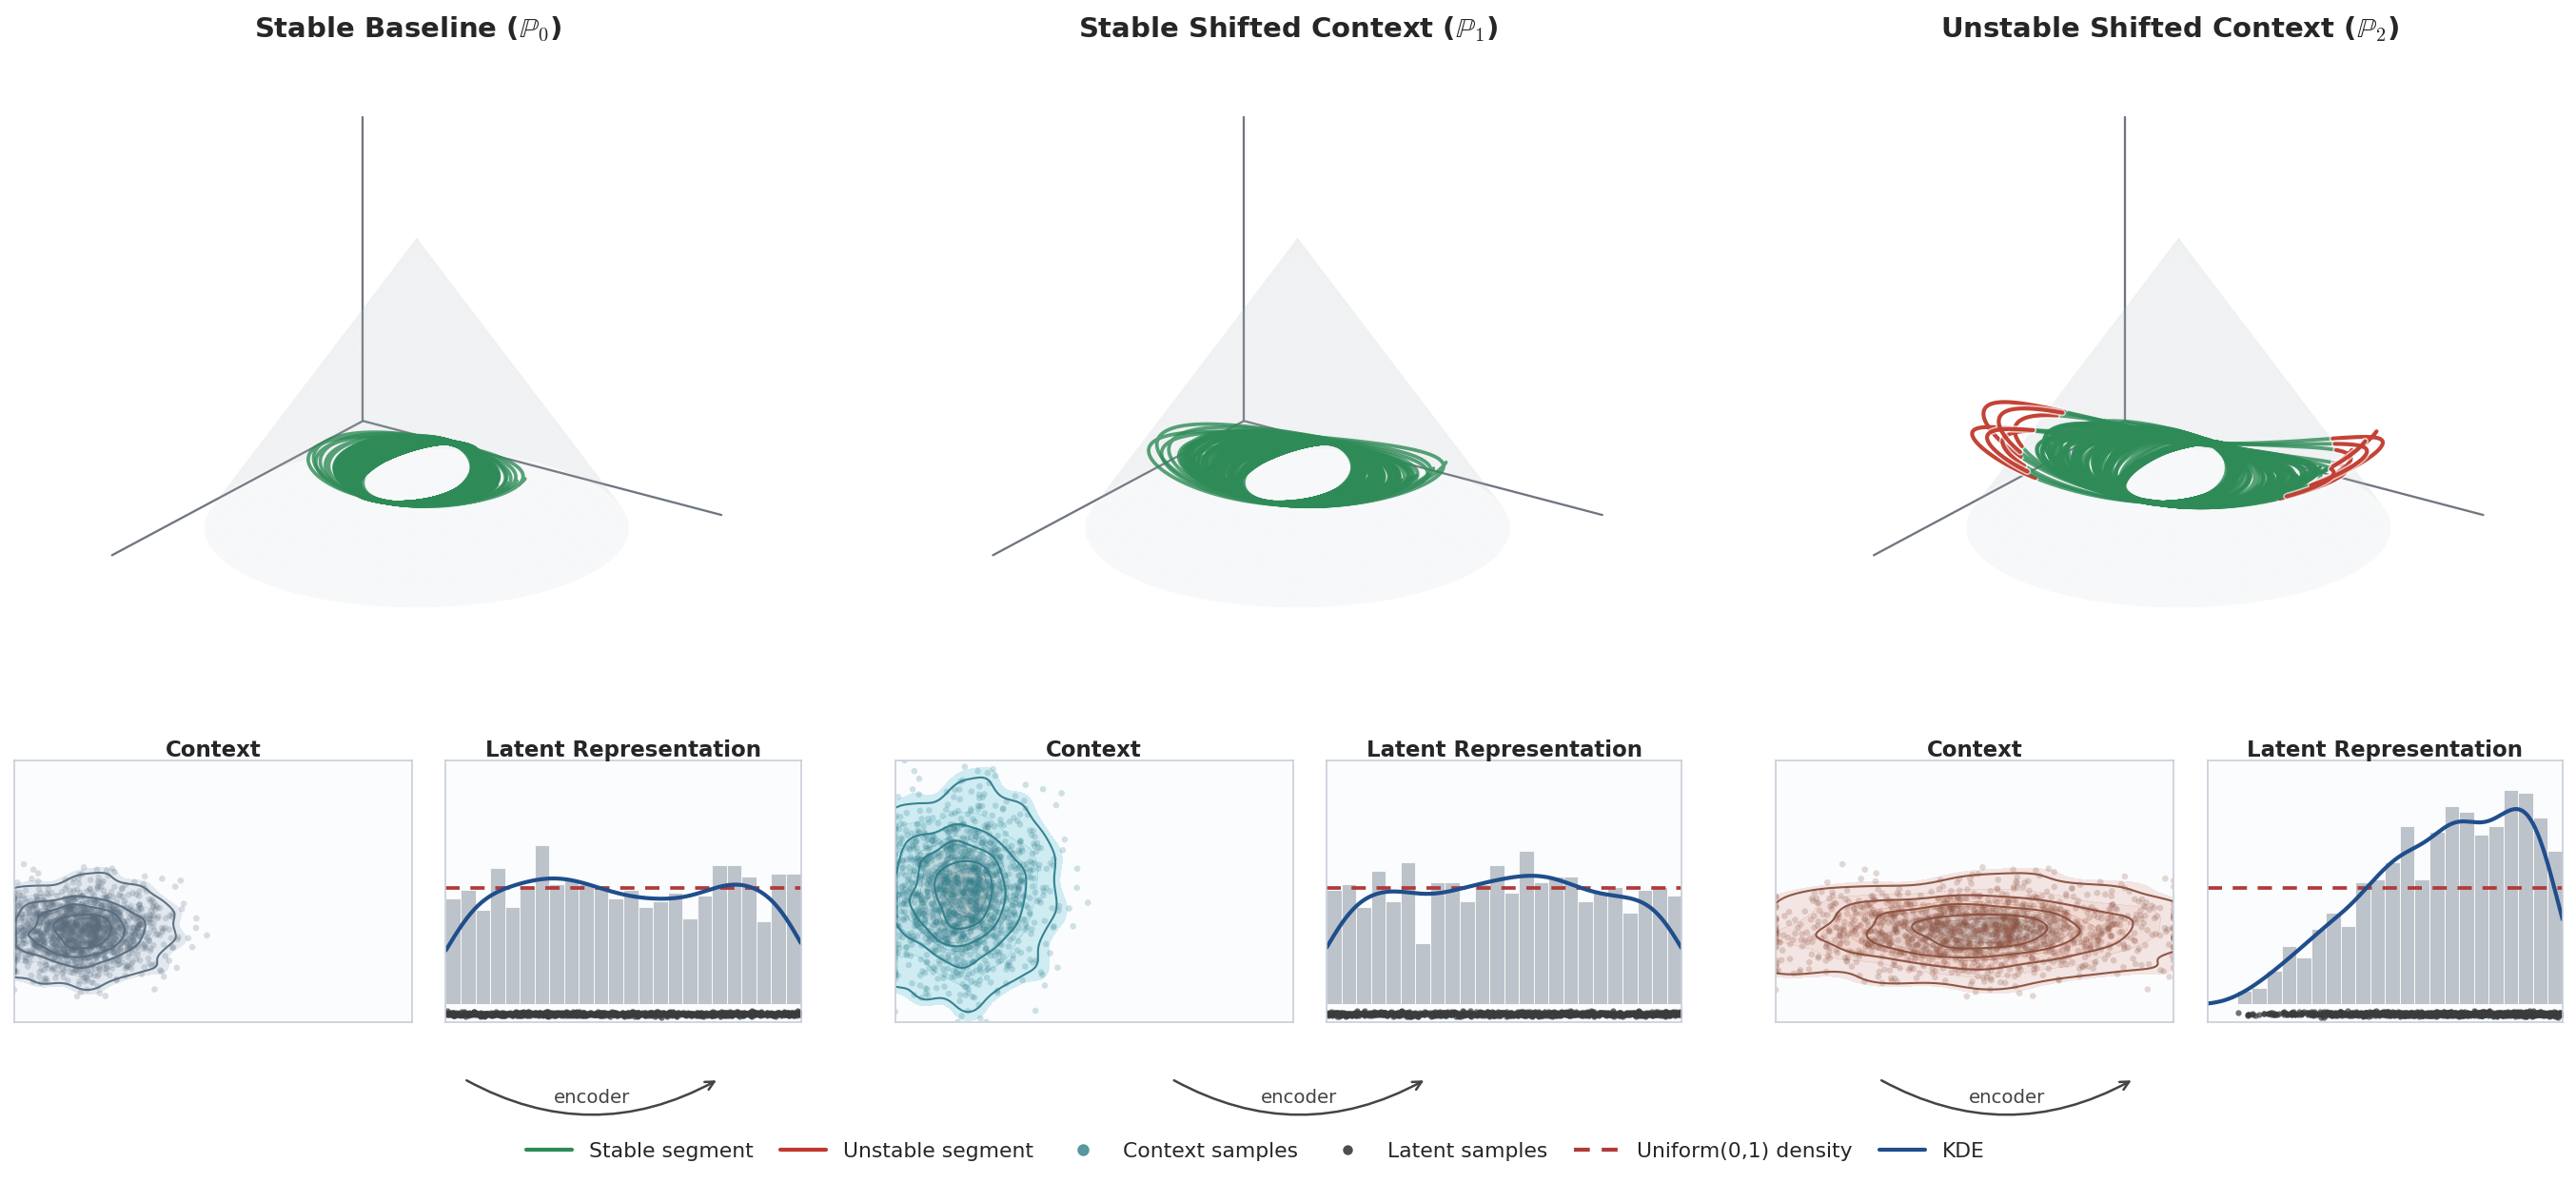

In [380]:
set_conference_style()
plot_three_column_nested(
    traj_safe, traj_still_safe, traj_risky,
    A_base, w_base, A_safe, w_safe, A_risky, w_risky,
    z_base=x_u, z_safe=x_v, z_risky=x_w,
    theta_max_deg=27, n_plot=30, cone_alpha=0.10
)
